<a href="https://colab.research.google.com/github/blakebordelon/deep_icl_regression_scaling_theory/blob/main/theory_scaling_law_ICL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Theory of Scaling Laws for In-Context Regression: Width, Depth, Context, and Time


### Motivating Questions

1. How do properties of tasks we train a transformer to perform influence the scope of its learned solution (how well it generalizes to other related tasks)?  
2. Transformers have many scaling dimensions including width, depth, context length. How do these tradeoff with one another? What is the compute optimal scaling strategy (given fixed # of flops or $$$ what is best I can do)?

### Model: In-Context Regression as a Solveable Setting


Depth $L$ linear attention model, trained with SGD on an in-context regression task.

Each context $c$ has a linear relationship $y_{\mu, c} = \beta_c \cdot x_\mu + \epsilon_{c,\mu}$. We sample a collection of $x_\mu$ from the

$$D = \begin{bmatrix} x_1 & x_2 & ... & x_P & x_{P+1} & ... & x_{P+K}
\\
y_1 & y_2 & ... & y_P & * & * & *
 \end{bmatrix} $$

 where $*$ indicates masked entries. The goal is to train the model to predict the masked entries for $x_{P+1},...,x_{P+K}$


### Scaling Variables

1. The depth $L$. We will see from the theory that for this task, this can be either the number of distinct attention blocks or the number of loops of a single attention block.
2. The width $N$, which quantifies the dimension of the residual stream. When $N$ is smaller than the input dimension, performance can suffer.
3. Context length $P$ is how many complete tokens we process in a given context.
4. Training time $t$ is how long we pretrain the model from a small weight initial condition.

### Our Main Findings

1. Properties of the data influence the tradeoff between depth, width, context length and training time.
2. Tasks need to be sufficiently diverse and challenging for the model to learn solutions that generalize to a wide set of tasks.
3. We can generate interesting predictions regarding the tradoffs between these variables. For powerlaw covariates, we find a scaling law of the form

$$\text{Loss} \sim c_t t^{-\alpha_t} + c_N N^{-\alpha_N} + c_L L^{-\alpha_L} + c_P P^{-\alpha_P}$$

Import necessary libraries

In [1]:
import jax.numpy as jnp
from jax import random, grad, lax
from typing import Any, Callable, Sequence
import jax
import optax
from jax import jit

from flax import linen as nn
import matplotlib.pyplot as plt
import numpy as np
from jax.example_libraries import optimizers

import seaborn as sns
import sys


sns.set(font_scale=1.3)
sns.set_style("whitegrid")
sns.set_palette("rocket", n_colors=10)

##

In [2]:
# X is B x seq x d
def model_eval(params, X, y, L=100, P_test = 1, beta = 100.0, qk_ln = False, norm_inputs = False):

  W_x, W_y, Wq, Wk, Wv, w_out = params

  N , d = W_x.shape

  # load in the input data
  h = jnp.einsum('ijk,lk->ijl', X, W_x)
  if norm_inputs:
    h = h / jnp.sqrt(d)

  seq_len = X.shape[1]
  P_tr = seq_len - P_test

  # mask y data so that only P_tr have labels
  # that the model can access
  mask_y = np.ones( y.shape )
  mask_y[:,P_tr:] = np.zeros(( B, P_test))

  h = h + jnp.einsum('ij,k->ijk', y * mask_y , W_y) # B x P x N

  print(h.shape)

  mask = np.ones((seq_len, seq_len))
  mask[:,P_tr:] = np.zeros( (seq_len , P_test ))
  mask = jnp.array(mask)

  train_losses = []
  test_loss = []
  for l in range(L):
    train_losses += [  jnp.mean( h[:,:P_tr,-1]**2 )  ]
    test_loss += [ jnp.mean( ( h[:,P_tr:,-1] + y[:,P_tr:] ) **2 ) ]

    q = jnp.einsum('ijk,lk->ijl', h,  Wq) / jnp.sqrt(N) # contract over N dimension
    k = jnp.einsum('ijk,lk->ijl', h,  Wk) / jnp.sqrt(N)

    if qk_ln:
      q = q - q.mean(axis = -1, keepdims = True)
      k = k - k.mean(axis = -1, keepdims = True)
      q = q / jnp.sqrt( jnp.mean( q**2 , axis = -1, keepdims = True ) )
      k = k / jnp.sqrt( jnp.mean( k**2 , axis = -1, keepdims = True ) )

    v = jnp.einsum('ijk,lk->ijl', h,  Wv) / jnp.sqrt(N)
    A = jnp.einsum('ijk,ilk->ijl', k, q) / N   # B x P x P


    # mask the attention
    h = h - beta/L * jnp.einsum('ijk,ilj->ilk', v,  jnp.einsum('ijk,jk->ijk', A, mask)  ) / P_tr

  out = jnp.einsum('ijk,k->ij', h, w_out) / N
  return out , train_losses, test_loss

def model_eval_decoupled(params, X, y, L=100, P_test = 1, beta = 100.0, qk_ln = False, norm_inputs = False):

  W_x, W_y, Wq, Wk, Wv, w_out = params

  N , d = W_x.shape

  # load in the input data
  hx = jnp.einsum('ijk,lk->ijl', X, W_x)

  seq_len = X.shape[1]
  P_tr = seq_len - P_test

  # mask y data
  mask_y = np.ones( y.shape )
  mask_y[:,P_tr:] = np.zeros(( B, P_test ))

  hy = jnp.einsum('ij,k->ijk', y * mask_y , W_y) # B x P x N


  mask = np.ones((seq_len, seq_len))
  mask[:,P_tr:] = np.zeros( (seq_len , P_test ))
  mask = jnp.array(mask)


  for l in range(L):

    q = jnp.einsum('ijk,lk->ijl', hx,  Wq) / jnp.sqrt(N) # contract over N dimension
    k = jnp.einsum('ijk,lk->ijl', hx,  Wk) / jnp.sqrt(N)

    v = jnp.einsum('ijk,lk->ijl', hy,  Wv) / jnp.sqrt(N)
    A = jnp.einsum('ijk,ilk->ijl', k, q) / N   # B x P x P


    # mask the attention
    hy = hy - beta/L * jnp.einsum('ijk,ilj->ilk', v,  jnp.einsum('ijk,jk->ijk', A, mask)  ) / P_tr

  #out = jnp.einsum('ijk,k->ij', hy, w_out) / N
  out = jnp.einsum('ijk,k->ij', hy, W_y) / N
  return out , [], []

# wo = wy
def model_eval_decoupled_frozen_emb(params_tr, Wy , X, y, L=100, P_test = 1, beta = 100.0, qk_ln = False, norm_inputs = False):

  W_x, Wq, Wk, Wv = params_tr

  N , d = W_x.shape

  # load in the input data
  hx = jnp.einsum('ijk,lk->ijl', X, W_x)

  seq_len = X.shape[1]
  P_tr = seq_len - P_test

  # mask y data
  mask_y = np.ones( y.shape )
  mask_y[:,P_tr:] = np.zeros(( B, P_test ))

  hy = jnp.einsum('ij,k->ijk', y * mask_y , Wy) # B x P x N


  mask = np.ones((seq_len, seq_len))
  mask[:,P_tr:] = np.zeros( (seq_len , P_test ))
  mask = jnp.array(mask)


  for l in range(L):

    q = jnp.einsum('ijk,lk->ijl', hx,  Wq) / jnp.sqrt(N) # contract over N dimension
    k = jnp.einsum('ijk,lk->ijl', hx,  Wk) / jnp.sqrt(N)

    v = jnp.einsum('ijk,lk->ijl', hy,  Wv) / jnp.sqrt(N)
    A = jnp.einsum('ijk,ilk->ijl', k, q) / N   # B x P x P


    # mask the attention
    hy = hy - beta/L * jnp.einsum('ijk,ilj->ilk', v,  jnp.einsum('ijk,jk->ijk', A, mask)  ) / P_tr

  #out = jnp.einsum('ijk,k->ij', hy, w_out) / N
  out = jnp.einsum('ijk,k->ij', hy, Wy) / N
  return out , [], []


### Some utilities for sampling different Context Matrices

1. Isotropic features $x \sim N(0,1)$
2. Random rotation $x \sim {N}(0, \Sigma_c)$ where $\Sigma_c = O_c \Lambda O_c^\top$ and $O_c \sim \text{Haar}(O_N)$

In [3]:

def sample_data(d, B, P_tr, P_te, seed = 0):

  X = random.normal(random.PRNGKey(2*seed), (B, P_tr + P_te , d))
  betas = random.normal( random.PRNGKey(2*seed + 1), (B,d) )
  y = jnp.einsum('ijk,ik->ij', X, betas) / jnp.sqrt(d) # B x (P + P_test)
  return X, y

# gaussian data with non-white spectrum
def sample_data_spec(spec, w_star, B, P_tr, P_te, seed = 0):

  d = spec.shape[0]
  X = random.normal(random.PRNGKey(2*seed+1), (B, P_tr + P_te , d))
  X = jnp.einsum('ijk,k->ijk', X, spec**(0.5))


  betas = random.normal( random.PRNGKey(2*seed + 2), (B,d) )
  y = jnp.einsum('ijk,ik->ij', X, betas)  # B x (P + P_test)
  return X, y


def sample_data_spec_rotate(spec, w_star, B, P_tr, P_te, seed = 0):

  d = spec.shape[0]
  X = random.normal(random.PRNGKey(2*seed+1), (B, P_tr + P_te , d))
  X = jnp.einsum('ijk,k->ijk', X, spec**(0.5))


  O = jnp.linalg.qr( random.normal(random.PRNGKey(2*seed), (B, d, d)) )[0]
  betas = jnp.einsum('ijk,k->ij', O, w_star)
  y = jnp.einsum('ijk,ik->ij', X, betas)  # B x (P + P_test)

  return X, y

def sample_data_gauss_rotate(spec, w_star, B, P_tr, P_te, seed = 0):

  d = spec.shape[0]
  O = random.normal( random.PRNGKey(2*seed), (B, d, d) ) / jnp.sqrt(d)
  X = random.normal(random.PRNGKey(2*seed+1), (B, P_tr + P_te , d))
  X = jnp.einsum('ijk,k->ijk', X, spec**(0.5))
  X = jnp.einsum('ijk,ilk->ijl', X , O)

  betas = jnp.einsum('ijk,k->ij', O, w_star)
  y = jnp.einsum('ijk,ik->ij', X, betas)  # B x (P + P_test)

  return X, y


def init_params(d, N, sigma = 0.4):


  W_x = jnp.sqrt(2.0) * jnp.sqrt(N) * sigma * jnp.eye(N)

  W_y = jnp.ones(N)

  Wq = sigma * jnp.eye(N) * jnp.sqrt(N)

  Wk = 1.0 * Wq

  Wv = sigma * jnp.eye(N) * jnp.sqrt(N)

  w_out = 1.0 * W_y

  params = [ W_x, W_y, Wq , Wk, Wv, w_out]
  return params


In [ ]:
sample_data_gauss_rotate = jax.jit( sample_data_gauss_rotate , static_argnums= (2,3,4))
sample_data_spec_rotate = jax.jit( sample_data_spec_rotate , static_argnums= (2,3,4))

In [4]:
def train_model( data_params, model_params , opt_params, spec = None, w_star = None, random_rotate = True, unrestricted = False, online = True):

  d, P_tr, P_test, B = data_params

  N, L, beta, gamma = model_params

  T, lr, lamb = opt_params


  params = init_params(d, N)
  W_x, Wy, Wq, Wk, Wv, w_out = params

  params_tr = [W_x, Wq, Wk, Wv]

  loss_fn = lambda pt, X, y: jnp.mean( ( model_eval_decoupled_frozen_emb(pt, Wy, X, y, L = L, P_test=P_test, beta = beta, qk_ln=False)[0][:,P_tr:] / gamma + y[:,P_tr:] )**2 )
  if unrestricted:
    loss_fn = lambda pt, X, y: jnp.mean( ( model_eval(pt, X, y, L = L, P_test=P_test, beta = beta, qk_ln=False)[0][:,P_tr:] / gamma + y[:,P_tr:] )**2 )
    params_tr = [ W_x, Wy, Wq, Wk, Wv, w_out ]

  loss_fn = jax.jit(loss_fn)

  reg_loss_fn = lambda pt, X, y: N * gamma**2 * loss_fn(pt, X, y) + lamb * optimizers.l2_norm(pt)**2

  opt_init, opt_update, get_params = optimizers.sgd( lr )
  #opt_state = opt_init(params)
  opt_state = opt_init(params_tr)
  loss_grad_fn = jax.jit( jax.value_and_grad(reg_loss_fn) )


  pretrain_loss = []

  if online==False:
    train_loss = []

  for t in range(T):

    if online:
      seed_t = t
    else:
      seed_t = 0

    if spec is not None:
      if random_rotate:
        X , y = sample_data_spec_rotate(spec, w_star, B, P_tr, P_test, seed = seed_t)
      else:
        X, y = sample_data_spec( spec, w_star, B, P_tr, P_test, seed = seed_t)
    else:
      X, y = sample_data(d, B, P_tr, P_test, seed = t)
    _ , grads = loss_grad_fn(get_params(opt_state), X, y)
    loss = loss_fn(get_params(opt_state), X, y)
    opt_state = opt_update(t, grads, opt_state)

    if online:
      pretrain_loss += [ loss ]
    else:
      X , y = sample_data_spec_rotate(spec, w_star, B, P_tr, P_test, seed = seed_t+1)
      test_loss = loss_fn(get_params(opt_state), X, y)
      pretrain_loss += [test_loss]
      train_loss += [ loss ]


    if t % 100 == 0:
      if online:
        sys.stdout.write(f'\r step {t} , loss = {loss}')
      else:
        sys.stdout.write(f'\r step {t} , train loss = {loss}, test loss = {test_loss}')

  if online==False:
    return pretrain_loss, train_loss

  return pretrain_loss

## Isotropic Covariates.

In this case, the data $x \in \mathbb{R}^D$ are sampled as

$$x_\mu \sim {N}(0, I) \ , \ y_\mu = \frac{1}{\sqrt D} \beta \cdot x_\mu + \epsilon_\mu$$

One can show that if batch size $B = O(D)$ and number of labeled $P$ and unlabeled $K$ tokens per context are both $P,K = O(D)$, then SGD pretraining occurs on timescales of $O(1)$.

### Claim: For context $P$ and data dimension $D$, the depth $L$ is only useful (reduces the loss) if $P/D=\alpha < \infty$.

We analyze the joint scaling limit $P,D \to \infty$ with $P/D=\alpha$.


We use the following code to compute the response $R(t) = \text{tr} \left< \left(1-\eta P^{-1} XX^\top \right)^t \right>$. The loss is $L(t) = R(2t)$.

In [5]:
# computes the response function
# the loss is L(t) =  vs[2 * t]
def isotropic_DMFT(alpha, gamma, T, iters = 100):

  Theta = gamma * jnp.tril( jnp.ones((T,T)) , k=-1)

  H = jnp.linalg.inv( jnp.eye(T) + Theta )
  for n in range(iters):

    H = jnp.linalg.inv( jnp.eye(T) + Theta @ jnp.linalg.inv(jnp.eye(T) + 1/alpha *  H @ Theta) )

  vs = H @ jnp.ones(T)
  return vs

###Fast Expt for Tutorial

In [14]:
d = 16
P_test = 16
B = 256

#alpha = 1.25
alpha = 0.0
spec = jnp.linspace(1,d,d)**(- alpha)
spec = spec / jnp.sum(spec)

beta = 1.75
w_star = jnp.sqrt( jnp.linspace(1, d, d)**(-alpha*beta-1.0) / spec )
w_star = w_star / jnp.sqrt( jnp.sum( w_star**2 * spec ) )

T = 1000
lr =  0.25

lamb = 1.0e-14
beta_model = 1.0

# initialize N=d
N = d
params = init_params(d, N)

gamma = 1.0



all_losses = []

P_trs = [ 8, 16, 32, 64 ]
Lvals = [1, 2, 4]


for i, P_tr in enumerate(P_trs):
  print("")
  print(f"P = {P_tr}")
  all_loss_i = []
  for j, L in enumerate(Lvals):
    data_params = [d, P_tr, P_test, B]
    model_params = [ N , L, beta_model , gamma]
    opt_params = [T, lr, lamb]

    pretrain_loss = train_model(data_params, model_params, opt_params, spec = spec, w_star = w_star, random_rotate=False)
    all_loss_i += [pretrain_loss]
  all_losses += [all_loss_i]


P = 8
 step 900 , loss = 0.5595402717590332
P = 16
 step 900 , loss = 0.2942070960998535
P = 32
 step 900 , loss = 0.09358341991901398
P = 64
 step 900 , loss = 0.020355405285954475

In [17]:
alpha_vals = jnp.logspace(-1, 1.0, 100)
all_losses_th = [isotropic_DMFT(alpha,  1.0 / (1.0 + 1.0/alpha) , 64) for alpha in alpha_vals]
loss_np = jnp.array(all_losses_th).T

In [18]:
all_losses_tr = jnp.array( [ [ loss[-1] for loss in loss_i] for loss_i in all_losses ]  ).T
all_losses_std = jnp.array( [ [  jnp.array([ loss[-k]  for k in range(10)]).std() / jnp.sqrt(20) for loss in loss_i] for loss_i in all_losses ]  ).T


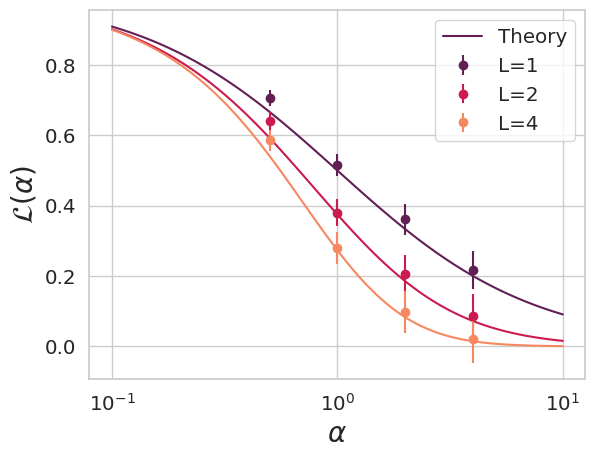

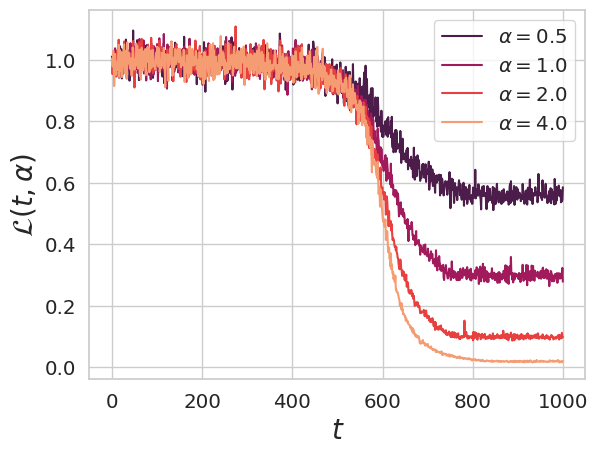

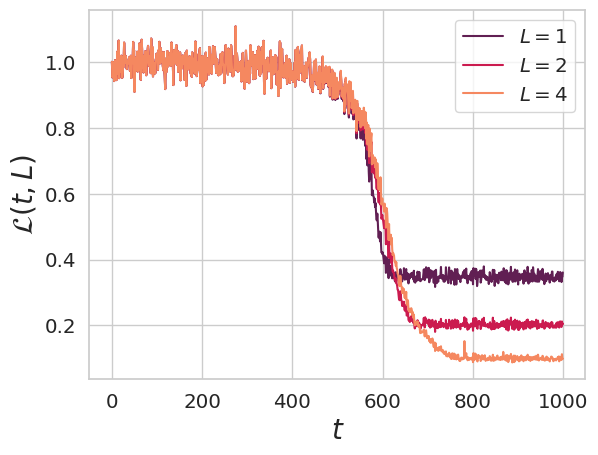

In [19]:
sns.set_palette("rocket", n_colors=len(Lvals))
for i,L in enumerate(Lvals):
  plt.semilogx(alpha_vals, loss_np[2*L], color = f'C{i}')
  plt.errorbar( jnp.array(P_trs)/d, all_losses_tr[i] , all_losses_std[i], fmt='o', color = f'C{i}',label = f'L={L}' )
plt.semilogx([],[],color = f'C{0}', label = 'Theory')
plt.xlabel(r'$\alpha$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}(\alpha)$',fontsize = 20)
plt.legend()
plt.show( )


sns.set_palette("rocket", n_colors=len(P_trs))
for i, P in enumerate(P_trs):
    plt.plot(  all_losses[i][-1] , label = r'$\alpha = %0.1f$' % (1.0 * P/d ) )
plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}(t, \alpha)$',fontsize = 20)
plt.legend()
plt.show( )


sns.set_palette("rocket", n_colors=len(Lvals))
for i, L in enumerate(Lvals):
    plt.plot(  all_losses[2][i] , label = f'$L = {L}$')
plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}(t, L)$',fontsize = 20)
plt.legend()
plt.show( )

### Full Expt

In [ ]:
d = 32
P_test = 32
B = 512

#alpha = 1.25
alpha = 0.0
spec = jnp.linspace(1,d,d)**(- alpha)
spec = spec / jnp.sum(spec)

beta = 1.75
w_star = jnp.sqrt( jnp.linspace(1, d, d)**(-alpha*beta-1.0) / spec )
w_star = w_star / jnp.sqrt( jnp.sum( w_star**2 * spec ) )

T = 6000
lr =  0.125

lamb = 1.0e-14
beta_model = 1.0

N = d

params = init_params(d, N)

gamma = 1.0



all_losses = []

P_trs = [ 8, 16, 32, 64, 128, 256 ]
Lvals = [1,2,4,8,16]


for i, P_tr in enumerate(P_trs):
  print("")
  print(f"P = {P_tr}")
  all_loss_i = []
  for j, L in enumerate(Lvals):
    data_params = [d, P_tr, P_test, B]
    model_params = [ N , L, beta_model , gamma]
    opt_params = [T, lr, lamb]

    pretrain_loss = train_model(data_params, model_params, opt_params, spec = spec, w_star = w_star, random_rotate=False)
    all_loss_i += [pretrain_loss]
  all_losses += [all_loss_i]


P = 8
 step 5900 , loss = 0.7682389616966248
P = 16
 step 5900 , loss = 0.5175752639770508
P = 32
 step 5900 , loss = 0.16040068864822388
P = 64
 step 5900 , loss = 0.023771654814481735
P = 128
 step 5900 , loss = 0.007592231035232544
P = 256
 step 5900 , loss = 0.003995387814939022

In [ ]:
alpha_vals = jnp.logspace(-1, 1.0, 100)
all_losses_th = [isotropic_DMFT(alpha,  1.0 / (1.0 + 1.0/alpha) , 512) for alpha in alpha_vals]
loss_np = jnp.array(all_losses_th).T

In [ ]:
all_losses_tr = jnp.array( [ [ loss[-1] for loss in loss_i] for loss_i in all_losses ]  ).T
all_losses_std = jnp.array( [ [  jnp.array([ loss[-k]  for k in range(10)]).std() / jnp.sqrt(20) for loss in loss_i] for loss_i in all_losses ]  ).T


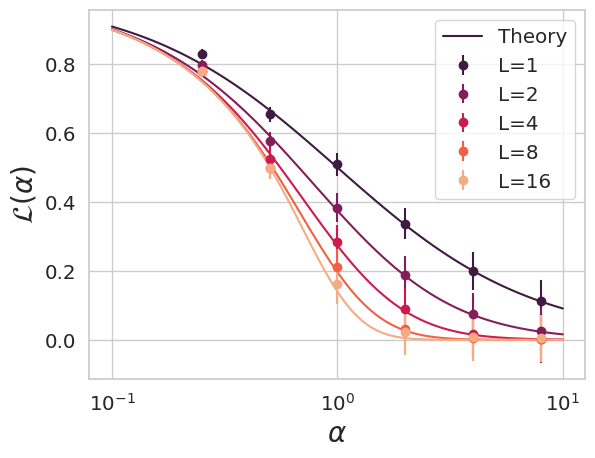

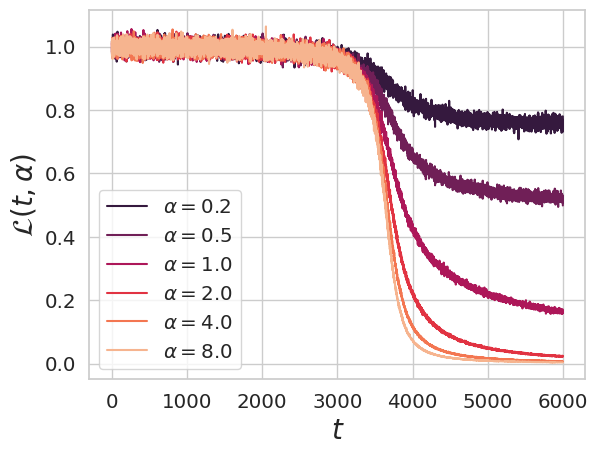

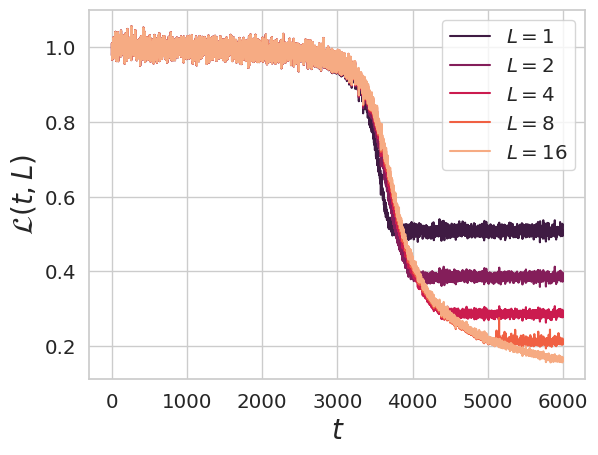

In [ ]:
sns.set_palette("rocket", n_colors=len(Lvals))
for i,L in enumerate(Lvals):
  plt.semilogx(alpha_vals, loss_np[2*L], color = f'C{i}')
  plt.errorbar( jnp.array(P_trs)/d, all_losses_tr[i] , all_losses_std[i], fmt='o', color = f'C{i}',label = f'L={L}' )
plt.semilogx([],[],color = f'C{0}', label = 'Theory')
plt.xlabel(r'$\alpha$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}(\alpha)$',fontsize = 20)
plt.legend()
plt.savefig('depth_vs_alpha_isotropic.pdf',bbox_inches = 'tight')
plt.show( )


sns.set_palette("rocket", n_colors=len(P_trs))
for i, P in enumerate(P_trs):
    plt.plot(  all_losses[i][-1] , label = r'$\alpha = %0.1f$' % (1.0 * P/d ) )
plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}(t, \alpha)$',fontsize = 20)
plt.legend()
plt.savefig('train_dynamics_vary_alpha.pdf',bbox_inches = 'tight')
plt.show( )


sns.set_palette("rocket", n_colors=len(Lvals))
for i, L in enumerate(Lvals):
    plt.plot(  all_losses[2][i] , label = f'$L = {L}$')
plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}(t, L)$',fontsize = 20)
plt.legend()
plt.savefig('train_dynamics_vary_L.pdf',bbox_inches = 'tight')
plt.show( )

### Verify that SGD Noise Effects are Controlled in Our Scaling

Consider the joint scaling of dimension $D$, context train $P$ and context test tokens $K$ and batch size $B$ as
$$D,P,K,B \to \infty \ , \ P/D = \alpha \ , \ K/D=\kappa \ , \ B/D = \tau$$

This implies that we need to see $O(D^2)$ tokens for SGD to converge which is intuitive given that $\Gamma \in \mathbb{R}^{D \times D}$ has $D^2$ free parameters to estimate.  

In [ ]:
def simple_SGD_isotropic_dynamics(d, B, P, eta = 0.01, T=100):

  M = jnp.eye(d)

  losses = []
  for t in range(T):

    Betas =  random.normal(random.PRNGKey(2*t), (B, d))
    Xs =  random.normal(random.PRNGKey(2*t+1), (B, P, d))
    losses += [1/d * jnp.sum(M**2)]

    Omegas = jnp.einsum('ijk,ijl->ikl', Xs, Xs) / P # B x d x d

    Beta_outer = jnp.einsum('ij,ik->ijk', Betas, Betas)

    M += - eta / B * jnp.einsum('ijk,kl,ilm->jm', Beta_outer, M, Omegas)

  return losses



def simple_SGD_isotropic_theory(tau, kappa, eta = 0.01, T=100):


  tvals = jnp.linspace(1,T,T)

  losses = jnp.exp(tvals * jnp.log( (1-eta)**2  + eta**2/tau * (1+1/kappa) ))

  return losses

In [ ]:
d = 512
tau = 0.025
eta = 0.02

alpha = 0.5
B = int(tau * d)
P = int(alpha * d)

taus = [0.05, 0.1, 0.2, 0.4]
losses = [ simple_SGD_isotropic_dynamics(d, int(tau*d), int(alpha*d), eta, T=100) for tau in taus]
losses_th = [ simple_SGD_isotropic_theory(tau, alpha, eta, T=100) for tau in taus]

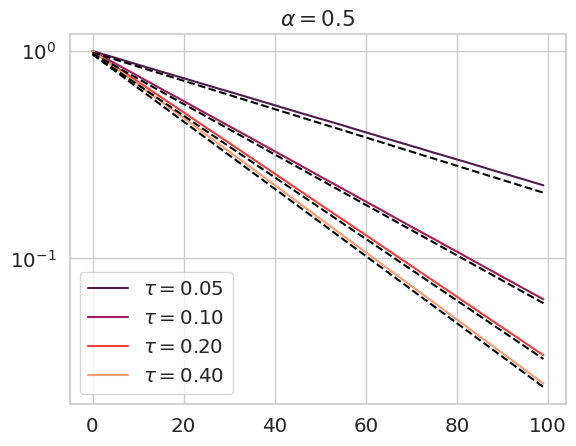

In [ ]:

sns.set_palette("rocket", n_colors=len(losses))
plt.title(r'$\alpha = %0.1f$' % alpha)
for i,loss in enumerate(losses):
  plt.semilogy(loss, label = r'$\tau = %0.2f$' % taus[i])
for i,loss in enumerate(losses_th):
  plt.semilogy(loss, '--', color = 'black')
plt.legend()
plt.show()

In [ ]:
d = 512
tau = 0.025

alpha = 2.0
B = int(tau * d)
P = int(alpha * d)

taus = [0.05, 0.1, 0.2, 0.4]
losses = [ simple_SGD_isotropic_dynamics(d, int(tau*d), int(alpha*d), eta, T=100) for tau in taus]
losses_th = [ simple_SGD_isotropic_theory(tau, alpha, eta, T=100) for tau in taus]

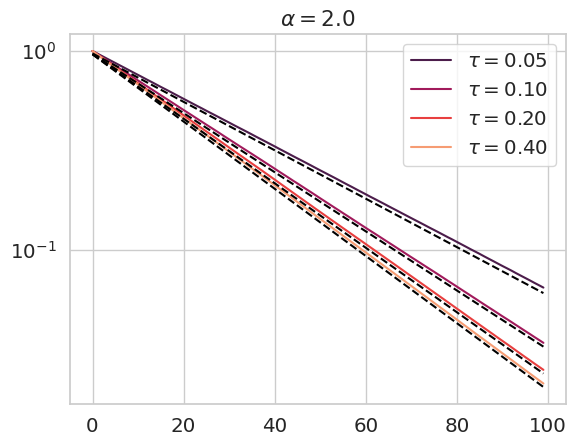

In [ ]:

sns.set_palette("rocket", n_colors=len(losses))
plt.title(r'$\alpha = %0.1f$' % alpha)
for i,loss in enumerate(losses):
  plt.semilogy(loss, label = r'$\tau = %0.2f$' % taus[i])
for i,loss in enumerate(losses_th):
  plt.semilogy(loss, '--', color = 'black')
plt.legend()
plt.show()

In [ ]:
def simple_SGD_RMT_isotropic_dynamics(d, B, K, P, eta = 0.01, T=100):

  Gamma = jnp.zeros((d,d))

  losses = []
  for t in range(T):

    Betas =  random.normal(random.PRNGKey(3*t), (B, d))
    Xs =  random.normal(random.PRNGKey(3*t+1), (B, K, d))
    Xtes = random.normal(random.PRNGKey(3*t+2), (B, P, d))



    losses += [1/d * jnp.sum(  ( jnp.eye(d) - Gamma )**2  )]


    Omegas = jnp.einsum('ijk,ijl->ikl', Xs, Xs) / K # B x d x d
    Sigmas = jnp.einsum('ijk,ijl->ikl', Xtes, Xtes) / P

    Beta_outer = jnp.einsum('ij,ik->ijk', Betas, Betas)

    M_eff = jnp.einsum('i,jk->ijk', jnp.ones(B), jnp.eye(d)) -  jnp.einsum('jk,ikl->ijl', Gamma, Sigmas)
    Gamma +=  eta / B * jnp.einsum('ijk,ikl,ilm,imn->jn', Omegas, M_eff, Beta_outer, Sigmas)

  return losses



def simple_SGD_RMT_isotropic_theory(tau, alpha, kappa, eta = 0.01, T=100):

  tvals = jnp.linspace(1,T,T)


  # C =

  a = 1.0 - 2*eta*(1+1/alpha) + eta**2*(1 + 1/tau*(1+1/kappa)*(1+1/alpha)) * (1+1/alpha)
  b = eta**2*( 1 + 1/tau * (1+1/kappa) * (1 + 1/alpha)  ) / (1+alpha)

  a_t = jnp.exp( tvals * jnp.log(a) )

  C = alpha**2/(1+alpha)**2 * a_t + (1-a_t)/(1-a) * b


  losses = C  + 2 / (1+1/alpha) * 1/(1+alpha) * jnp.exp(tvals * jnp.log(1-eta*(1+1/alpha)) ) + 1.0/(1+alpha)**2

  return losses

In [ ]:
d = 256
tau = 0.025

eta=0.03

alpha = 1.0
kappa = 4.0

B = int(tau * d)
P = int(alpha * d)
K = int(kappa * d)

taus = [0.1, 0.2, 0.4, 0.8, 1.6]
losses = [ simple_SGD_RMT_isotropic_dynamics(d,int(tau*d),K,P,eta, T=100) for tau in taus]
losses_th = [ simple_SGD_RMT_isotropic_theory(tau, alpha, kappa, eta, T=100) for tau in taus]

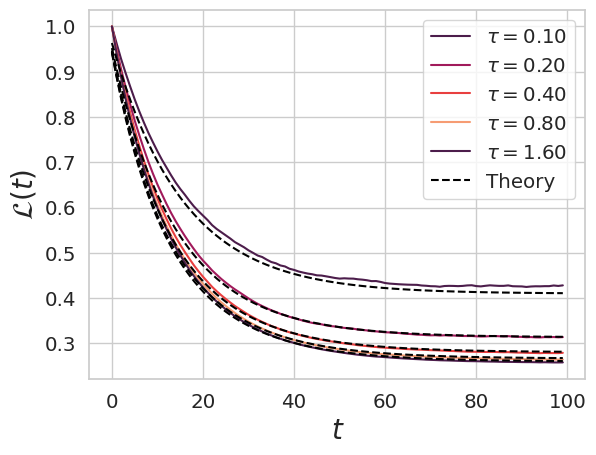

In [ ]:
for i, loss in enumerate(losses):
  plt.plot(loss,label = r'$\tau = %0.2f$' % taus[i])

for i, loss in enumerate(losses_th):
  plt.plot(loss, '--', color = 'black')
plt.plot([],[], '--', color = 'black', label ='Theory')
plt.legend()
plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}(t)$',fontsize =20)
plt.savefig(f'loss_vary_tau_depth_1_alpha_{alpha}.pdf', bbox_inches ='tight')
plt.show()

In [ ]:
d = 256
tau = 0.025

eta=0.03

alpha = 1.0
kappa = 4.0

tau = 1.0

B = int(tau * d)
P = int(alpha * d)
K = int(kappa * d)

alphas = [0.1, 0.2, 0.4, 0.8, 1.6]

losses = [ simple_SGD_RMT_isotropic_dynamics(d, B, K, int(alpha*d),eta, T=100) for alpha in alphas]
losses_th = [ simple_SGD_RMT_isotropic_theory(tau, alpha, kappa, eta, T=100) for alpha in alphas]

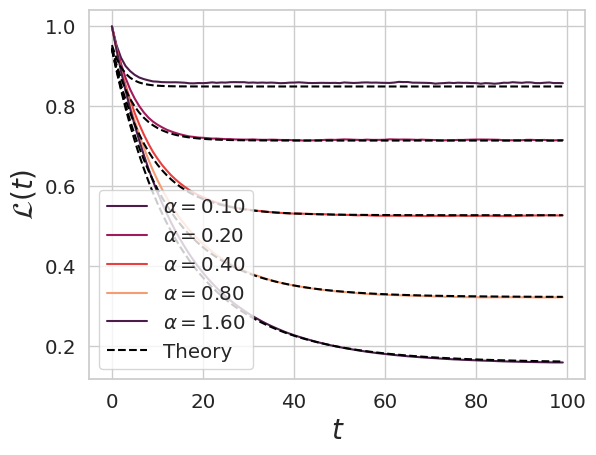

In [ ]:
for i, loss in enumerate(losses):
  plt.plot(loss,label = r'$\alpha = %0.2f$' % alphas[i])

for i, loss in enumerate(losses_th):
  plt.plot(loss, '--', color = 'black')
plt.plot([],[], '--', color = 'black', label ='Theory')
plt.legend()
plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}(t)$',fontsize =20)
plt.savefig(f'loss_vary_alpha_depth_1_tau_{tau}.pdf', bbox_inches ='tight')
plt.show()

In [ ]:
d = 256
tau = 0.025

eta=0.03

alpha = 1.0
tau = 1.0

B = int(tau * d)
P = int(alpha * d)
K = int(kappa * d)

kappas = [0.1, 0.2, 0.4, 0.8, 1.6]

losses = [ simple_SGD_RMT_isotropic_dynamics(d, B, int(kappa*d), P,eta, T=100) for kappa in kappas]
losses_th = [ simple_SGD_RMT_isotropic_theory(tau, alpha, kappa, eta, T=100) for kappa in kappas]

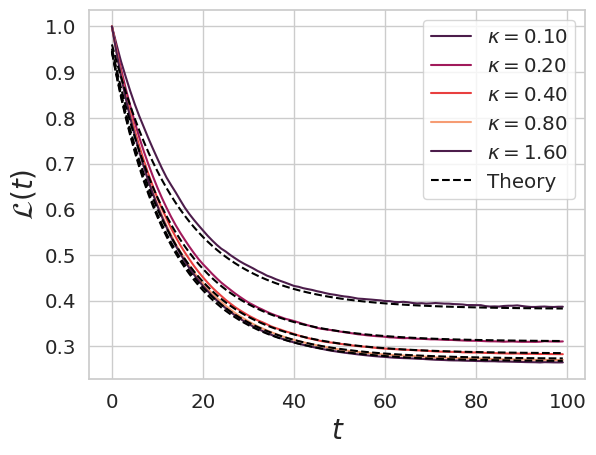

In [ ]:
for i, loss in enumerate(losses):
  plt.plot(loss,label = r'$\kappa = %0.2f$' % kappas[i])

for i, loss in enumerate(losses_th):
  plt.plot(loss, '--', color = 'black')
plt.plot([],[], '--', color = 'black', label ='Theory')
plt.legend()
plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}(t)$',fontsize =20)
plt.savefig(f'loss_vary_kappa_depth_1_alpha_{alpha}.pdf', bbox_inches ='tight')
plt.show()

In [ ]:
d = 256
tau = 0.025

eta=0.03

alpha = 8.0
kappa = 2.0

B = int(tau * d)
P = int(alpha * d)
K = int(kappa * d)

taus = [0.1, 0.2, 0.4, 0.8, 1.6]
losses = [ simple_SGD_RMT_isotropic_dynamics(d,int(tau*d),K,P,eta, T=100) for tau in taus]
losses_th = [ simple_SGD_RMT_isotropic_theory(tau, alpha, kappa, eta, T=100) for tau in taus]

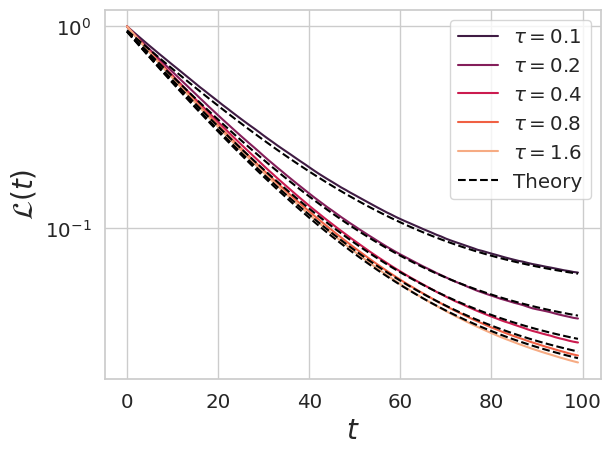

In [ ]:
sns.set_palette("rocket", n_colors=len(losses))

for i, loss in enumerate(losses):
  plt.semilogy(loss,label = r'$\tau = %0.1f$' % taus[i])

for i, loss in enumerate(losses_th):
  plt.semilogy(loss, '--', color = 'black')
plt.semilogy([],[], '--', color = 'black',label = 'Theory')
plt.legend()
plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}(t)$',fontsize =20)
plt.savefig(f'loss_vary_tau_depth_1_alpha_{alpha}.pdf', bbox_inches ='tight')
plt.show()

In [ ]:
def simple_SGD_noisy_RMT_isotropic_dynamics(d, B, K, P, sigma = 0.0, eta = 0.01, T=100):

  Gamma = jnp.zeros((d,d))

  losses = []
  for t in range(T):

    Betas =  random.normal(random.PRNGKey(4*t), (B, d))
    Xs =  random.normal(random.PRNGKey(4*t+1), (B, K, d))
    Xtes = random.normal(random.PRNGKey(4*t+2), (B, P, d))

    eps = random.normal(random.PRNGKey(4*t+3), (B, P, d))

    losses += [1/d * jnp.sum(  ( jnp.eye(d) - Gamma )**2  )]

    # v =  (I - Gamma Sigma)v + sqrt(D)/P * sigma * X eps

    b = sigma * jnp.einsum('ijk,ij->ik', Xtes, eps) / P * jnp.sqrt(d)

    Omegas = jnp.einsum('ijk,ijl->ikl', Xs, Xs) / K # B x d x d
    Sigmas = jnp.einsum('ijk,ijl->ikl', Xtes, Xtes) / P

    Beta_outer = jnp.einsum('ij,ik->ijk', Betas, Betas)

    M_eff = jnp.einsum('i,jk->ijk', jnp.ones(B), jnp.eye(d)) -  jnp.einsum('jk,ikl->ijl', Gamma, Sigmas)
    Gamma +=  eta / B * jnp.einsum('ijk,ikl,ilm,imn->jn', Omegas, M_eff, Beta_outer, Sigmas)

  return losses

In [ ]:
def visualize_loss_landscape(gamma, lamb_grid , alpha, L, sigma=0.0):

  min = (1 - 1/jnp.sqrt(alpha))**2
  max = (1 + 1/jnp.sqrt(alpha))**2


  diff = (max - lamb_grid)*(lamb_grid - min)
  rho = alpha/(2*jnp.pi * lamb_grid) * jnp.sqrt( diff * (diff > 0.0) ) # bulk spectrum
  # function [1-gamma lambda]^{2L} + sigma^2 / alpha * (  )

  dlamb = (jnp.amax(lamb_grid)-jnp.amin(lamb_grid)) / len(lamb_grid)

  #loss_lamb =  + sigma**2/alpha * (1.0-(1.0-gamma*lamb_grid)**L)**2/lamb_grid

  loss_lamb = jnp.exp( 2*L*jnp.log(jnp.abs(1.0 - gamma*lamb_grid/L )) )

  #loss_lambsigma**2/alpha * (1.0-jnp(1.0-gamma*lamb_grid)**L)**2/lamb_grid
  loss = jnp.sum( rho * loss_lamb * dlamb )

  loss += sigma**2 / alpha * jnp.sum( dlamb * rho * ( 1.0 - ( 1.0 - gamma*lamb_grid / L )**L )**2 / lamb_grid )
  loss += (1-alpha) * (alpha < 1.0)
  return loss

In [ ]:
lamb_grid = jnp.linspace(0.01,10,100)
alpha = 1.25
L = 10
sigma = 0.2
gamma_vals = jnp.linspace(0, 1.0, 50)
losses = [ visualize_loss_landscape(gamma, lamb_grid, alpha, L) for gamma in gamma_vals ]

[9.10311341e-01 6.16426945e-01 4.56471145e-01 3.60097378e-01
 2.96457708e-01 2.51240134e-01 2.17296243e-01 1.90757513e-01
 1.69365451e-01 1.51712224e-01 1.36872202e-01 1.24209255e-01
 1.13270447e-01 1.03723802e-01 9.53193605e-02 8.78653824e-02
 8.12117010e-02 7.52389655e-02 6.98510855e-02 6.49694726e-02
 6.05294704e-02 5.64770512e-02 5.27668409e-02 4.93611507e-02
 4.62322906e-02 4.33845147e-02 4.09631841e-02 3.97205427e-02
 4.27666605e-02 6.15108013e-02 1.34130672e-01 3.78760695e-01
 1.13674951e+00 3.33630419e+00 9.36817360e+00 2.50971642e+01
 6.42904739e+01 1.57998505e+02 3.73744995e+02 8.53554504e+02
 1.88712305e+03 4.04891626e+03 8.44871387e+03 1.71790938e+04
 3.40979414e+04 6.61698984e+04 1.25724273e+05 2.34189781e+05
 4.28174500e+05 7.69211500e+05]


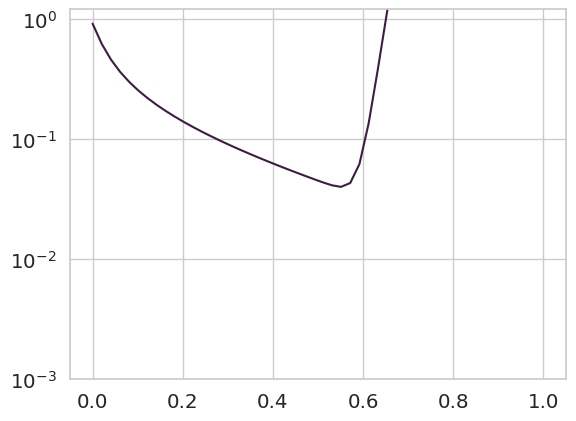

In [ ]:
print(jnp.array(losses))
plt.semilogy(gamma_vals, losses)
plt.ylim([1e-3,1.2])
plt.show()

In [ ]:
Lvals = [ 1,2,4,8,16,32 ]
alpha = 0.5
lamb_grid = jnp.linspace(0.01,10,100)
sigma = 0.0
gamma_vals = jnp.linspace(0, 1.0, 100)

all_losses = [ [ visualize_loss_landscape(L* gamma,  lamb_grid, alpha, L) for gamma in gamma_vals ] for L in Lvals]

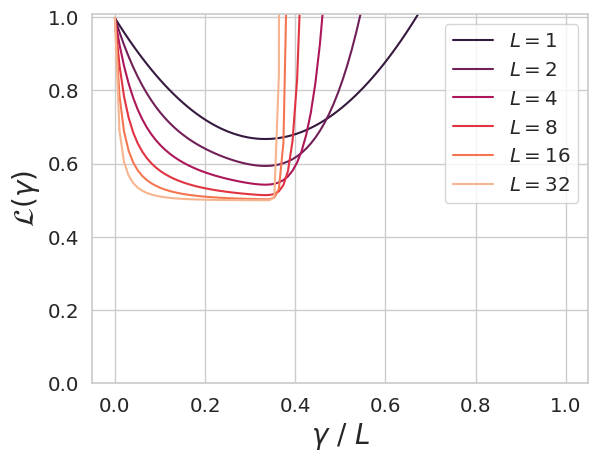

In [ ]:
sns.set_palette("rocket", n_colors=len(Lvals))

for i, L in enumerate(Lvals):
  plt.plot(gamma_vals, all_losses[i], label = f'$L = {L}$')

plt.legend()
plt.ylim([0,1.01])
plt.xlabel(r'$\gamma \ / \  L$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}(\gamma)$',fontsize=20)
plt.savefig(f'loss_landscape_gamma_alpha_{alpha}.pdf',bbox_inches='tight')
plt.show()

In [ ]:
L = 16
alpha = 1.125
lamb_grid = jnp.linspace(0.01,10,100)
sigmas = [0.0, 0.25, 0.5, 0.75, 1.0]
gamma_vals = jnp.linspace(0, 1.0, 100)

all_losses = [ [ visualize_loss_landscape(L*gamma, lamb_grid, alpha, L, sigma = sigma) for gamma in gamma_vals ] for sigma in sigmas]

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-2581399927.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(gamma_vals, all_losses[i], label = f'$\sigma = {sigma}$')


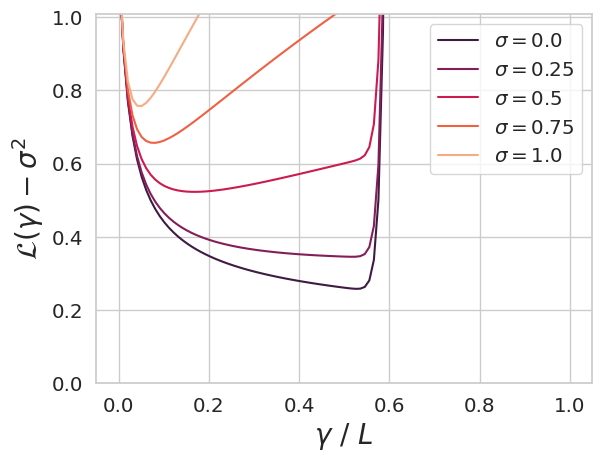

In [ ]:
sns.set_palette("rocket", n_colors=len(sigmas))

for i, sigma in enumerate(sigmas):
  plt.plot(gamma_vals, all_losses[i], label = f'$\sigma = {sigma}$')
plt.legend()
plt.ylim([0,1.01])
plt.xlabel(r'$\gamma \ / \ L$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}(\gamma)-\sigma^2$',fontsize=20)
plt.savefig(f'loss_landscape_gamma_vary_sigma.pdf',bbox_inches='tight')
plt.show()

## Reduced Model Dynamics + Scaling Laws

We notice that we can capture the expressivity of the model with

$$\Gamma = (w_0^\top W_V w_y) W_x^\top W_k^\top W_q W_x \in \mathbb{R}^{D \times D}$$

In this section, we work directly with this matrix to simplify the analysis. We train on structured but randomly rotated covariates.

In [20]:
def reduced_Gamma_structured_SGD_RMT_isotropic_dynamics(spec, beta_bar, N, L, B, K, P, sigma = 0.0, eta = 0.01, T=100, lamb = 1e-3, rotate=True, ctx_sample=True):

  d = len(spec)
  Gamma = jnp.zeros((N,N))

  #Gamma = jnp.zeros((d,d))


  #A = random.normal(random.PRNGKey(0), (N, d))

  A = np.zeros((N,d))
  m = min(N,d)
  A[:m,:m] += np.eye(m) * jnp.sqrt(N)
  A = jnp.array(A)

  losses = []

  @jax.jit
  def compute_loss(Gamma, A, Os_t, Sigmas_t, betas_t):

    batch = Sigmas_t.shape[0]
    dim = Sigmas_t.shape[1]

    A_G_A = 1/N * A.T @ Gamma @ A
    #A_G_A = Gamma
    vs = 1.0 * betas_t
    M = jnp.einsum('i,jk->ijk', jnp.ones(batch), jnp.eye(dim))
    M = M - 1/L * jnp.einsum('jk,ikl->ijl', A_G_A, Sigmas_t)

    for l in range(L):
      vs = jnp.einsum('ijk,ik->ij', M, vs)

    Ov = jnp.einsum('ijk,ij->ik', Os_t, vs) # O.T @ v
    return jnp.einsum('ik,ik,k->', Ov, Ov, spec ) / batch + lamb * jnp.mean(Gamma**2)


  grad_loss = jit(grad(compute_loss, 0))

  losses = []
  var_eigs = []
  mean_eigs = [ ]

  get_O = jax.jit( lambda X: jnp.linalg.qr(X)[0] )
  for t in range(T):

    #### FINISH THIS

    d = spec.shape[0]


    #betas = random.normal( random.PRNGKey(2*seed + 1), (B,d) )

    O = get_O( random.normal(random.PRNGKey(3*t+1), (B, d, d)) )
    #O = jnp.linalg.qr( random.normal(random.PRNGKey(3*t+1), (B, d, d)) )[0]

    if ctx_sample:
      X = random.normal(random.PRNGKey(3*t), (B, P, d))
      X = jnp.einsum('ijk,k->ijk', X, spec**(0.5))
      OX = jnp.einsum('ijk,ilk->ilj', O, X)
      Sigma_c = jnp.einsum('ijk,ijl->ikl', OX, OX) / P # O Lambda_hat O^T
    else:
      Sigma_c = jnp.einsum('ijk,ilk,k->ijl', O, O, spec)

    bernoulli = random.bernoulli(random.PRNGKey(3*t+2), shape=(B,d))
    bernoulli = 2*bernoulli - 1.0
    w_sign = w_star[jnp.newaxis,:] * bernoulli

    betas = jnp.einsum('ijk,ik->ij', O, w_sign) # O beta_bar




    loss_t = compute_loss( Gamma, A, O, Sigma_c, betas)
    losses += [loss_t]
    Gamma += - eta * grad_loss(Gamma, A, O, Sigma_c, betas)

    eigs = jnp.linalg.eigvalsh( A.T @ Gamma @ A / N )

    var_eigs_t = ( jnp.mean( eigs**2 ) - jnp.mean(eigs)**2 ) / jnp.mean(eigs)**2
    mean_eigs += [jnp.mean(eigs)]
    sys.stdout.write(f'\r step = {t}  |  loss = {loss_t} | var_eigs = {var_eigs_t}')
    var_eigs += [var_eigs_t]

  return losses, mean_eigs, var_eigs

In [ ]:
#M = 2048
M = 64

alpha = 1.5
beta = 0.8

spec = jnp.linspace(1,M,M)**(-alpha)
w_star = jnp.linspace(1,M,M)**(- (alpha*beta+1 - alpha)*0.5 )

w_star= w_star / jnp.sqrt( jnp.sum(w_star**2 * spec)  )

def loss_fn(gammas, spec, w_star, L=4, lamb = 0.0):

  decay = ( 1 - 1.0 / L *  jnp.outer( gammas , spec) )**(2*L)
  return jnp.einsum('ij,j->i', decay, spec * w_star**2 )

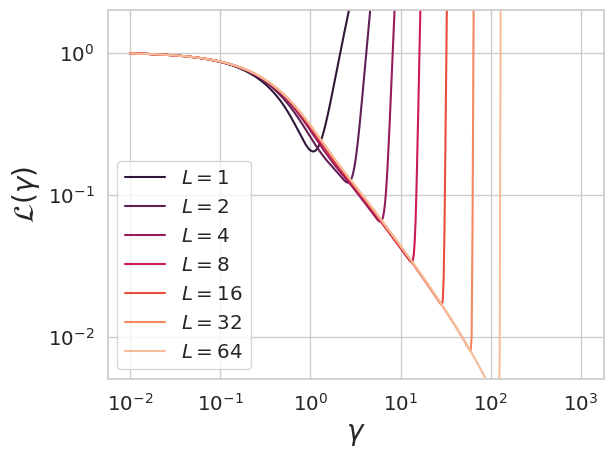

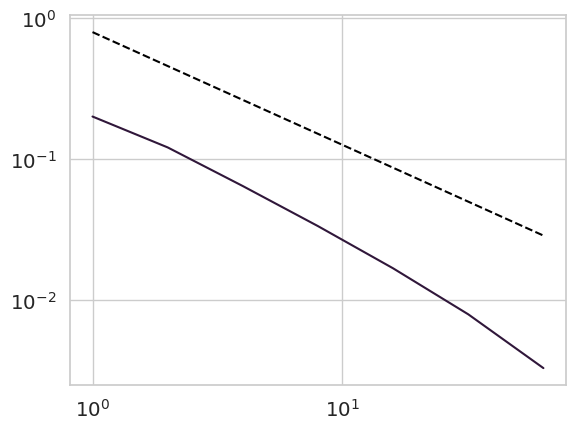

In [ ]:
gammas = jnp.logspace(-2,3.0,500)
Lvals = [1,2,4,8,16,32,64]
losses  = [ loss_fn(gammas, spec, w_star, L=L) for L in Lvals ]

sns.set_palette("rocket", n_colors=len(Lvals))
for i, loss in enumerate(losses):
  plt.loglog(gammas, loss, label = f'$L = {Lvals[i]}$')
plt.ylim([5e-3,2.0])
plt.legend()
plt.xlabel(r'$\gamma$',fontsize =20)
plt.ylabel(r'$\mathcal{L}(\gamma)$',fontsize=20)
plt.savefig('loss_landscape_powerlaw.pdf',bbox_inches = 'tight')
plt.show()

min_losses = [jnp.amin(loss) for loss in losses]

plt.loglog(Lvals, min_losses)
plt.loglog(Lvals, 0.8*jnp.array(Lvals)**(-beta), '--', color = 'black')
plt.show()

### Short example for tutorial

In [24]:
M = 45
N = 128
K = 16
B = 256
P = 256

Lvals= [1,2,4]
all_loss = []
T = 1000


alpha = 1.75
beta = 0.5


spec = jnp.linspace(1,M,M)**(-alpha)
w_star = jnp.linspace(1,M,M)**(- (alpha*beta+1 - alpha)*0.5 )
w_star= w_star / jnp.sqrt( jnp.sum(w_star**2 * spec)  )


for L in Lvals:
  print(f"L = {L}")
  losses, mean_eigs, var_eigs = reduced_Gamma_structured_SGD_RMT_isotropic_dynamics(spec, w_star, N, L, B, K, P, T = T, eta = 3.0)
  all_loss += [losses]

L = 1
 step = 999  |  loss = 0.31331905722618103 | var_eigs = 0.004832643549889326L = 2
 step = 999  |  loss = 0.22478629648685455 | var_eigs = 0.0006964009371586144L = 4
 step = 999  |  loss = 0.17766210436820984 | var_eigs = 0.00035541283432394266

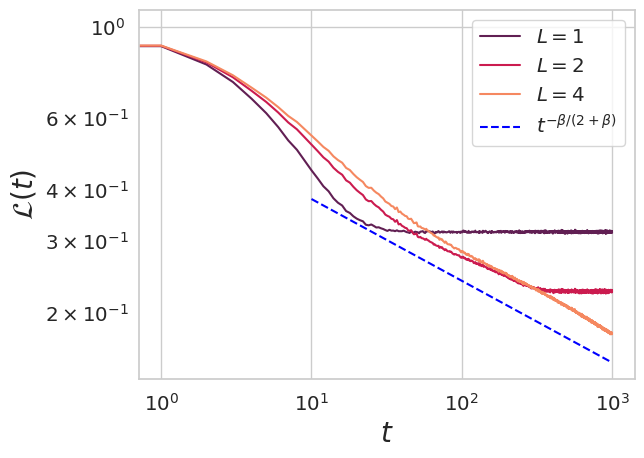

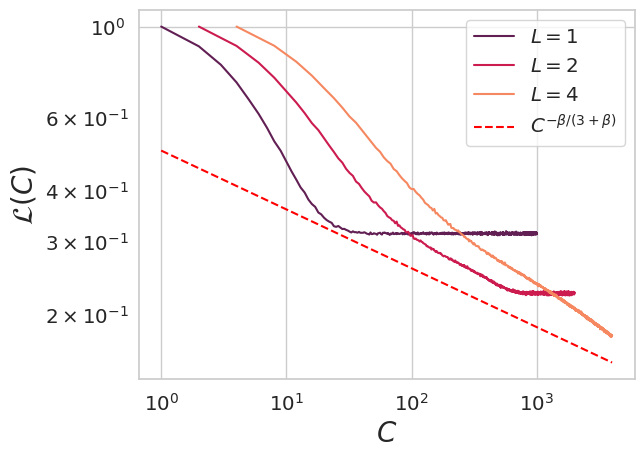

In [25]:
sns.set_palette("rocket", n_colors=len(Lvals))
for i, loss in enumerate(all_loss):
  plt.loglog(loss, label = f'$L = {Lvals[i]}$')
plt.loglog(jnp.linspace(10,T,T),  0.6* jnp.linspace(10,T,T)**(- beta/(2+beta) ) , '--',label = r'$t^{-\beta/(2+\beta)}$',color = 'blue')
plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}(t)$',fontsize = 20)
plt.legend()
#plt.savefig('losses_gamma_model_vary_L.pdf', bbox_inches = 'tight')
plt.show()


for i, loss in enumerate(all_loss):
  plt.loglog(Lvals[i] * jnp.linspace(1,len(loss),len(loss)), loss, label = f'$L = {Lvals[i]}$')
beta_t = beta/(2+beta)
plt.loglog(jnp.linspace(1,Lvals[i]*T,T), 0.5 * jnp.linspace(1,Lvals[i]*T,T)**(- beta/(beta+3.0) ) , '--', label = r'$C^{- \beta/(3+\beta) }$' , color = 'red')
plt.xlabel(r'$C$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}(C)$',fontsize = 20)
plt.legend()
#plt.savefig('losses_gamma_model_compute_vary_L.pdf', bbox_inches = 'tight')
plt.show()

### Full example from Paper

In [ ]:
M = 45
N = 256
K = 16
B = 512
P = 512

Lvals= [1,2,4,8,16]
all_loss = []
T = 20000


alpha = 1.75
beta = 0.5


spec = jnp.linspace(1,M,M)**(-alpha)
w_star = jnp.linspace(1,M,M)**(- (alpha*beta+1 - alpha)*0.5 )
w_star= w_star / jnp.sqrt( jnp.sum(w_star**2 * spec)  )


for L in Lvals:
  print(f"L = {L}")
  losses, mean_eigs, var_eigs = reduced_Gamma_structured_SGD_RMT_isotropic_dynamics(spec, w_star, N, L, B, K, P, T = T, eta = 3.0)
  all_loss += [losses]

 step = 19999  |  loss = 0.09286051988601685 | var_eigs = 0.27287477254867554

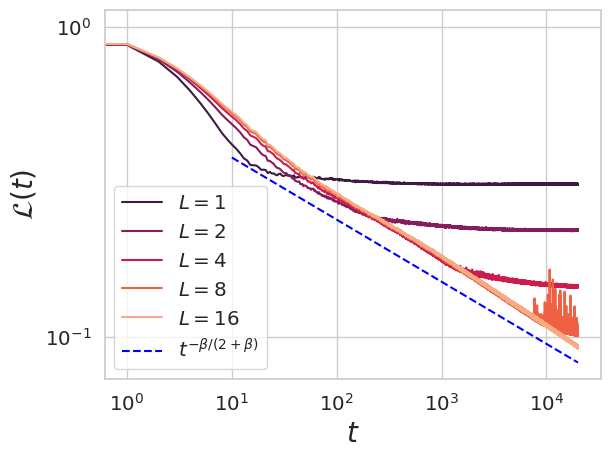

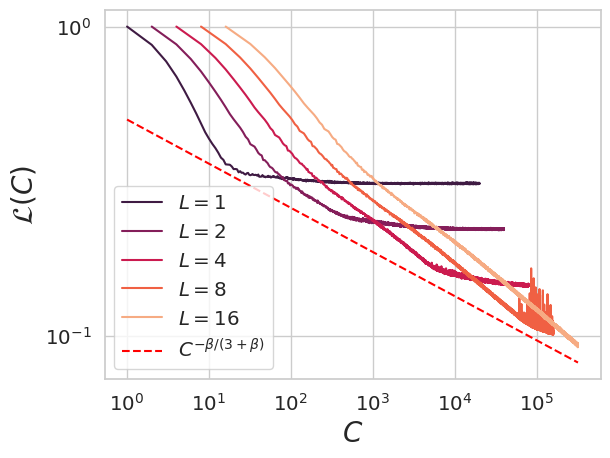

In [ ]:
sns.set_palette("rocket", n_colors=len(Lvals))
for i, loss in enumerate(all_loss):
  plt.loglog(loss, label = f'$L = {Lvals[i]}$')
plt.loglog(jnp.linspace(10,T,T),  0.6* jnp.linspace(10,T,T)**(- beta/(2+beta) ) , '--',label = r'$t^{-\beta/(2+\beta)}$',color = 'blue')
plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}(t)$',fontsize = 20)
plt.legend()
plt.savefig('losses_gamma_model_vary_L.pdf', bbox_inches = 'tight')
plt.show()


for i, loss in enumerate(all_loss):
  plt.loglog(Lvals[i] * jnp.linspace(1,len(loss),len(loss)), loss, label = f'$L = {Lvals[i]}$')
beta_t = beta/(2+beta)
plt.loglog(jnp.linspace(1,Lvals[i]*T,T), 0.5 * jnp.linspace(1,Lvals[i]*T,T)**(- beta/(beta+3.0) ) , '--', label = r'$C^{- \beta/(3+\beta) }$' , color = 'red')
plt.xlabel(r'$C$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}(C)$',fontsize = 20)
plt.legend()
plt.savefig('losses_gamma_model_compute_vary_L.pdf', bbox_inches = 'tight')
plt.show()

In [ ]:
L = 8
B = 256
Nvals= [16,32,64,128,256]
all_loss = []
T = 5000

for L in Lvals:
  losses, mean_eigs, var_eigs = reduced_Gamma_structured_SGD_RMT_isotropic_dynamics(spec, w_star, N, L, B, K, P, T = T, eta = 7.0)
  all_loss += [losses]

## Small Example for Tutorial Varying $\beta$

In [26]:
M = 64
N = 256
L = 8
B = 256
P = 512
K = 128
T = 1000


alpha = 1.5
beta = 1.0


beta_vals = [0.5, 1.0, 2.0]

# min{ 2, alpha*beta }

losses_vary_beta = []
for i, beta in enumerate(beta_vals):
  print(f"beta = {beta}")
  spec = jnp.linspace(1,M,M)**(-alpha)
  w_star = jnp.linspace(1,M,M)**(- (alpha*beta+1 - alpha)*0.5 )
  w_star= w_star / jnp.sqrt( jnp.sum(w_star**2 * spec)  )

  losses, mean_eigs, var_eigs = reduced_Gamma_structured_SGD_RMT_isotropic_dynamics(spec, w_star, N, L, B, K, P, T = T, eta = 5.0)
  losses_vary_beta += [losses]

beta = 0.5
 step = 999  |  loss = 0.17514364421367645 | var_eigs = 0.00045878050150349736beta = 1.0
 step = 999  |  loss = 0.0618445910513401 | var_eigs = 0.0006001565488986671beta = 2.0
 step = 999  |  loss = 0.013985901139676571 | var_eigs = 0.0007730270735919476

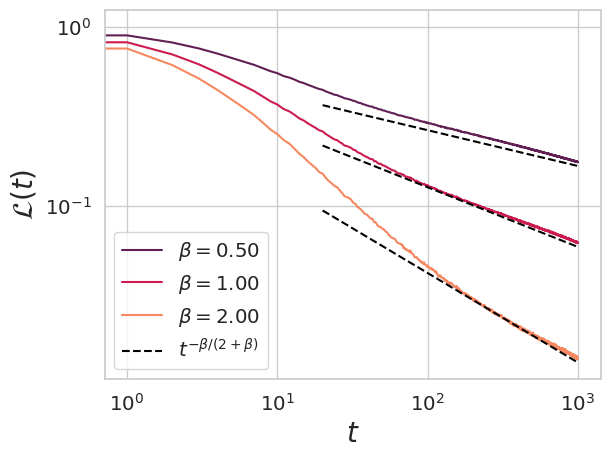

In [27]:
for i, loss in enumerate(losses_vary_beta):
  plt.loglog(loss, label = r'$\beta = %0.2f$' % beta_vals[i])
  beta_t = beta_vals[i] / (2+beta_vals[i])
  loss_th_i = jnp.linspace(20,T,T)**(- beta_t)
  plt.loglog( jnp.linspace(20,T,T), 0.95 * loss_th_i / loss_th_i[-1] * loss[-1] , '--', color = 'black')

plt.loglog([],[], '--' , color = 'black', label = r'$t^{- \beta/(2 + \beta)}$')
plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}(t)$',fontsize = 20)
plt.legend()
#plt.savefig('losses_vary_beta.pdf', bbox_inches = 'tight')
plt.show()

## Full Example of How Varying $\beta$ Changes scaling law in $t$

In [ ]:
M = 64
N = 512
L = 8
B = 256
P = 512
K = 128
T = 2000


alpha = 1.5
beta = 1.0


beta_vals = [0.5, 0.75, 1.0, 1.5, 2.0, 4.0]

# min{ 2, alpha*beta }

losses_vary_beta = []
for i, beta in enumerate(beta_vals):
  print(f"beta = {beta}")
  spec = jnp.linspace(1,M,M)**(-alpha)
  w_star = jnp.linspace(1,M,M)**(- (alpha*beta+1 - alpha)*0.5 )
  w_star= w_star / jnp.sqrt( jnp.sum(w_star**2 * spec)  )

  losses, mean_eigs, var_eigs = reduced_Gamma_structured_SGD_RMT_isotropic_dynamics(spec, w_star, N, L, B, K, P, T = T, eta = 5.0)
  losses_vary_beta += [losses]

 step = 1999  |  loss = 0.003846243489533663 | var_eigs = 0.13879579305648804

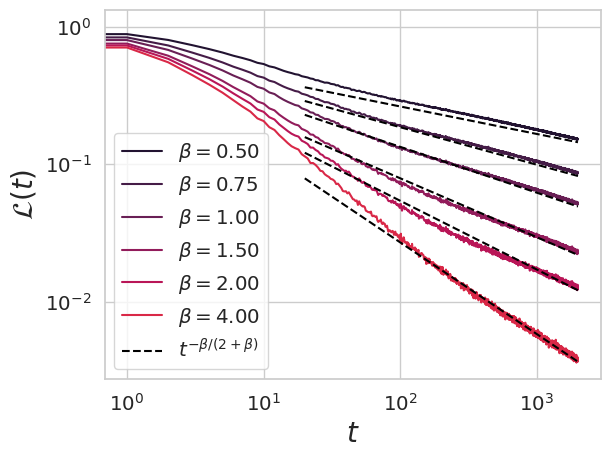

In [ ]:
for i, loss in enumerate(losses_vary_beta):
  plt.loglog(loss, label = r'$\beta = %0.2f$' % beta_vals[i])
  beta_t = beta_vals[i] / (2+beta_vals[i])
  loss_th_i = jnp.linspace(20,T,T)**(- beta_t)
  plt.loglog( jnp.linspace(20,T,T), 0.95 * loss_th_i / loss_th_i[-1] * loss[-1] , '--', color = 'black')

plt.loglog([],[], '--' , color = 'black', label = r'$t^{- \beta/(2 + \beta)}$')
plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}(t)$',fontsize = 20)
plt.legend()
plt.savefig('losses_vary_beta.pdf', bbox_inches = 'tight')
plt.show()

In [ ]:
M = 64
K = 32
B = 512
P = 512

Nvals = [ int(8 * 1.5**k) for k in range(5) ]

all_loss = []
T = 10000

alpha = 1.25
beta = 1.0

# N^{- alpha * beta} + L^{-beta} ,   N^{-alpha beta} = L^{-beta}


spec = jnp.linspace(1,M,M)**(-alpha)
w_star = jnp.linspace(1,M,M)**(- (alpha*beta+1 - alpha)*0.5 )
w_star= w_star / jnp.sqrt( jnp.sum(w_star**2 * spec)  )


L = 1
all_loss_no_scale = []
for i, N in enumerate(Nvals):
  print(f'N = {N}')
  losses, mean_eigs, var_eigs = reduced_Gamma_structured_SGD_RMT_isotropic_dynamics(spec, w_star, N, L, B, K, P, T = T, eta = 0.075, ctx_sample=False)
  all_loss_no_scale += [losses]

N = 8
Lvals_fix = [1,2,4,8,16]
all_loss_lin_scale = []
for i, L in enumerate(Lvals_fix):
  print(f'L = {L}')
  #L = int( N/8.0 )
  losses, mean_eigs, var_eigs = reduced_Gamma_structured_SGD_RMT_isotropic_dynamics(spec, w_star, N, L, B, K, P, T = T, eta = 0.075, ctx_sample=False)
  all_loss_lin_scale += [losses]


all_loss_opt_scale = []
for i, N in enumerate(Nvals):
  print(f'N = {N}')
  # N^{alpha} = L ,  N^2 L = C , L^{3 alpha} = C , L = C^{1/(3*alpha) }
  #L = int( (N/8.0)**alpha )
  L = int( N / 8.0 )
  losses, mean_eigs, var_eigs = reduced_Gamma_structured_SGD_RMT_isotropic_dynamics(spec, w_star, N, L, B, K, P, T = T, eta = 0.075, ctx_sample=False)
  all_loss_opt_scale += [losses]

N = 8
 step = 9999  |  loss = 0.4329701066017151 | var_eigs = 7.000991344451904N = 12
 step = 9999  |  loss = 0.347872257232666 | var_eigs = 4.334049224853516N = 18
 step = 9999  |  loss = 0.28992658853530884 | var_eigs = 2.5914804935455322N = 27
 step = 9999  |  loss = 0.2465074062347412 | var_eigs = 1.5923833847045898N = 40
 step = 9999  |  loss = 0.22123484313488007 | var_eigs = 1.0195281505584717L = 1
 step = 9999  |  loss = 0.4329701066017151 | var_eigs = 7.000991344451904L = 2
 step = 9999  |  loss = 0.3519664406776428 | var_eigs = 7.000504493713379L = 4
 step = 9999  |  loss = 0.3072953522205353 | var_eigs = 7.047763347625732L = 8
 step = 9999  |  loss = 0.29887571930885315 | var_eigs = 7.224523067474365L = 16
 step = 9999  |  loss = 0.2999635636806488 | var_eigs = 7.233870506286621N = 8
 step = 9999  |  loss = 0.4329701066017151 | var_eigs = 7.000991344451904N = 12
 step = 9999  |  loss = 0.347872257232666 | var_eigs = 4.334049224853516N = 18
 step = 9999  |  loss = 0.214094117

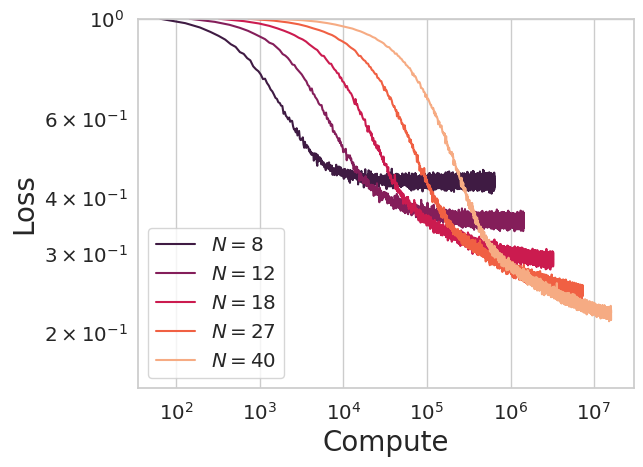

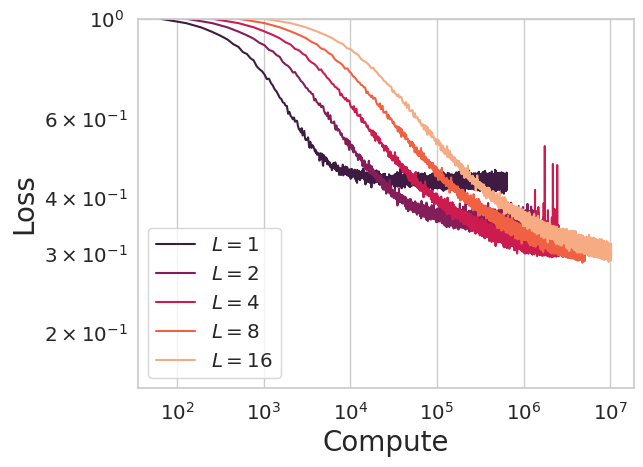

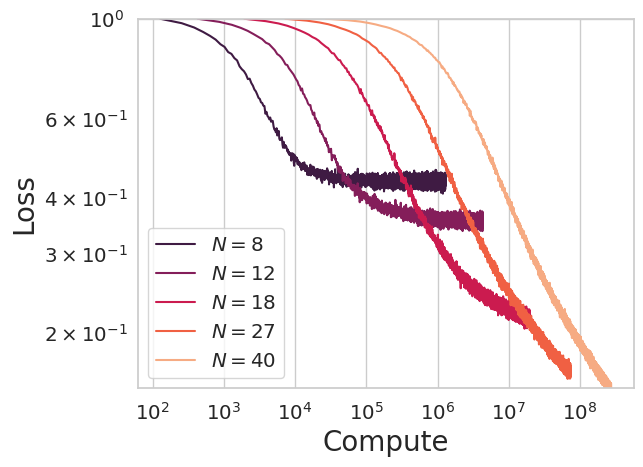

In [ ]:
sns.set_palette("rocket", n_colors=len(Nvals))


for i, N in enumerate(Nvals):

  plt.loglog(N**2 * jnp.linspace(1,T,T),  all_loss_no_scale[i],label=f'$N = {N}$')

plt.ylim([0.15,1.0])
plt.legend()
plt.xlabel(r'Compute', fontsize =20)
plt.ylabel(r'Loss',fontsize = 20)
plt.savefig('compute_scaling_fixed_L.pdf',bbox_inches = 'tight')
plt.show()

N=8
for i, L in enumerate(Lvals_fix):
  plt.loglog( L * N**2 * jnp.linspace(1,T,T),  all_loss_lin_scale[i], label = f'$L = {L}$', color = f'C{i}')

plt.legend()
plt.ylim([0.15,1.0])
plt.xlabel(r'Compute', fontsize =20)
plt.ylabel(r'Loss',fontsize = 20)
plt.savefig('compute_scaling_fixed_N.pdf',bbox_inches = 'tight')
plt.show()

for i, N in enumerate(Nvals):
  L = int( (N/4.0)**alpha )
  plt.loglog( L*N**2 * jnp.linspace(1,T,T), all_loss_opt_scale[i], label = f'$N = {N}$',color = f'C{i}')

plt.legend()
plt.ylim([0.15,1.0])
plt.xlabel(r'Compute', fontsize =20)
plt.ylabel(r'Loss',fontsize = 20)
plt.savefig('compute_scaling_joint_NL_scaling.pdf',bbox_inches = 'tight')
plt.show()


### Try again with sweeps giving equal final compute (more depth on depth only scaling, more width on width only scaling compared to final plot)

In [ ]:
M = 180
K = 32
B = 256
P = 512

Nvals = [ 16, 32, 64, 128, 256 ]

all_loss = []
T = 5000

alpha = 1.25
beta = 0.75

# N^{- alpha * beta} + L^{-beta} ,   N^{-alpha beta} = L^{-beta}


spec = jnp.linspace(1,M,M)**(-alpha)
w_star = jnp.linspace(1,M,M)**(- (alpha*beta+1 - alpha)*0.5 )
w_star= w_star / jnp.sqrt( jnp.sum(w_star**2 * spec)  )



In [ ]:
L = 1
#eta = 0.075
eta = 0.25
all_loss_no_scale = []
for i, N in enumerate(Nvals):
  print(f'N = {N}')

  losses, mean_eigs, var_eigs = reduced_Gamma_structured_SGD_RMT_isotropic_dynamics(spec, w_star, N, L, B, K, P, T = T, eta = eta, ctx_sample=False)
  all_loss_no_scale += [losses]

N = 16
 step = 4999  |  loss = 0.36614325642585754 | var_eigs = 3.000037670135498N = 32
 step = 4999  |  loss = 0.28352031111717224 | var_eigs = 1.000081181526184N = 64
 step = 4999  |  loss = 0.23401492834091187 | var_eigs = 0.00016359949950128794N = 128
 step = 4999  |  loss = 0.23400059342384338 | var_eigs = 0.00016369103104807436N = 256
 step = 4999  |  loss = 0.23399701714515686 | var_eigs = 0.00016359187429770827

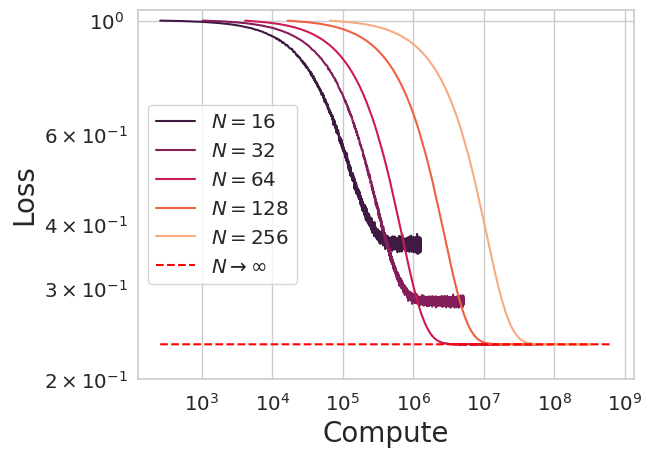

0.23406504


In [ ]:
sns.set_palette("rocket", n_colors=len(Nvals))
for i, N in enumerate(Nvals):
  plt.loglog(N**2 * jnp.linspace(1,T,T),  all_loss_no_scale[i],label=f'$N = {N}$')

loss_final = jnp.sum( (1.0 - 1.1*spec)**2 * w_star**2 * spec)
plt.plot( 16**2*jnp.linspace(1,500*T,T),  loss_final * jnp.ones(T), '--', color = 'red', label = r'$N \to \infty$')
plt.ylim([0.2,1.05])
plt.legend()
plt.xlabel(r'Compute', fontsize =20)
plt.ylabel(r'Loss',fontsize = 20)
plt.savefig('compute_scaling_fixed_L_more_width.pdf',bbox_inches = 'tight')
plt.show()
print(loss_final)

In [ ]:
N = 8
Lvals_fix = [1,2,4,8,16]
all_loss_lin_scale = []
#eta = 0.075
eta = 2.0

T = 25000

for i, L in enumerate(Lvals_fix):
  print(f'L = {L}')
  #L = int( N/8.0 )
  losses, mean_eigs, var_eigs = reduced_Gamma_structured_SGD_RMT_isotropic_dynamics(spec, w_star, N, L, B, K, P, T = T, eta = eta, ctx_sample=False, lamb = 1e-12)
  all_loss_lin_scale += [losses]

L = 1
 step = 24999  |  loss = 0.4928593933582306 | var_eigs = 7.000219821929932L = 2
 step = 24999  |  loss = 0.40638649463653564 | var_eigs = 7.000146389007568L = 4
 step = 24999  |  loss = 0.35802462697029114 | var_eigs = 7.000899791717529L = 8
 step = 24999  |  loss = 0.3446412682533264 | var_eigs = 7.0L = 16
 step = 24999  |  loss = 0.34570586681365967 | var_eigs = 7.000000953674316

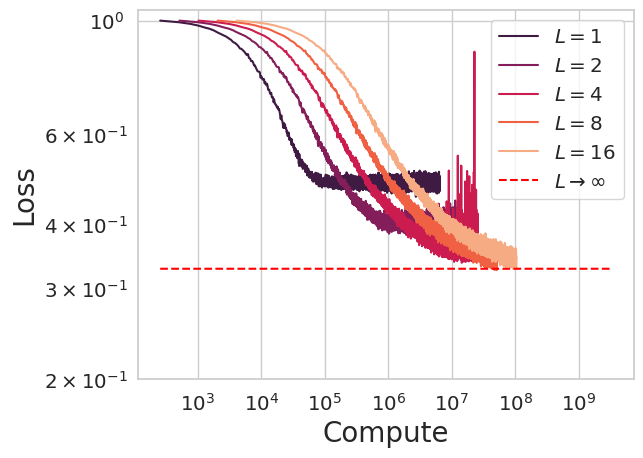

0.24098018


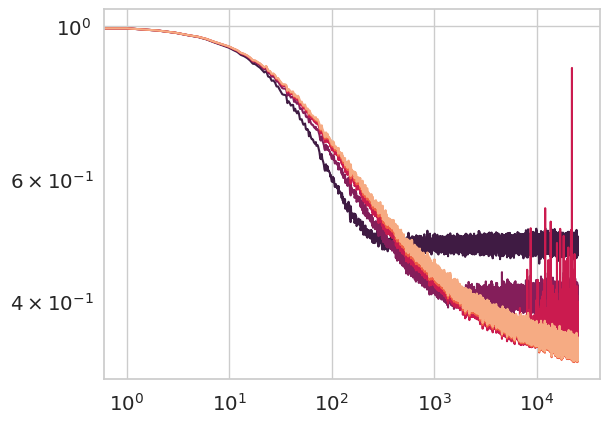

In [ ]:
sns.set_palette("rocket", n_colors=len(Lvals_fix))
for i, L in enumerate(Lvals_fix):
  plt.loglog(16**2 * L * jnp.linspace(1,T,T),  all_loss_lin_scale[i],label=f'$L = {L}$')
loss_final = jnp.sum( (1.0 - spec)**2 * w_star**2 * spec)
plt.plot( 16**2*jnp.linspace(1,500*T,T),  loss_8 * jnp.ones(T), '--', color = 'red', label = r'$L \to \infty$')
plt.ylim([0.2,1.05])
plt.legend()
plt.xlabel(r'Compute', fontsize =20)
plt.ylabel(r'Loss',fontsize = 20)
plt.savefig('compute_scaling_fixed_N_more_depth.pdf',bbox_inches = 'tight')
plt.show()
print(loss_final)

for i, L in enumerate(Lvals_fix):
  plt.loglog(all_loss_lin_scale[i],label=f'$L = {L}$')
plt.show()

In [ ]:
d = len(spec)
N = 8

a_vec = np.zeros(d)
a_vec[:N] = np.ones(N)

print(N)

z_small = 1e-6
all_loss_8 = []
for i in range(100):

  Q = jnp.linalg.qr( random.normal(random.PRNGKey(i), (d, d)) )[0]
  Matrix = Q @ jnp.diag( a_vec ) @ Q.T @ jnp.diag( spec )
  v_final = z_small * jnp.linalg.solve( Matrix + z_small * jnp.eye(spec.shape[0]) , w_star)

  all_loss_8 += [jnp.sum(v_final**2 * spec)]

loss_8 = jnp.mean(jnp.array(all_loss_8))
print(loss_8)

8
0.32850313


In [ ]:
#eta = 0.075
eta = 0.85
Nvals = [  4, 8 , 16,32, 64  ]
B = 64

T = 50000

all_loss_no_scale = []
for i, N in enumerate(Nvals):
  print(" ")
  print(f'N = {N}')
  L = int( (N/4.0)**(alpha) )
  losses, mean_eigs, var_eigs = reduced_Gamma_structured_SGD_RMT_isotropic_dynamics(spec, w_star, N, L, B, K, P, T = T, eta = eta, ctx_sample=False)
  all_loss_no_scale += [losses]


N = 4
 step = 49999  |  loss = 0.738469123840332 | var_eigs = 44.000083923339844N = 8
 step = 49999  |  loss = 0.5504944324493408 | var_eigs = 21.50004005432129N = 16
 step = 49999  |  loss = 0.344404399394989 | var_eigs = 10.250020980834961N = 32
 step = 49999  |  loss = 0.20984980463981628 | var_eigs = 4.625039577484131N = 64
 step = 49999  |  loss = 0.14019279181957245 | var_eigs = 1.812575101852417

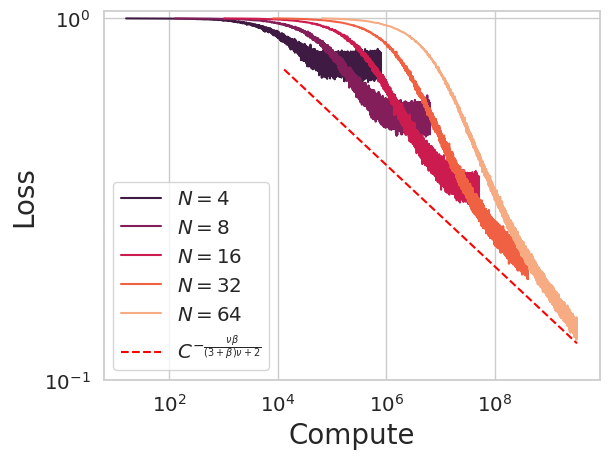

In [ ]:
sns.set_palette("rocket", n_colors=len(Nvals))
for i, N in enumerate(Nvals):
  plt.loglog(N**2 * int(N/4.0) * jnp.linspace(1,T,T),  all_loss_no_scale[i],label=f'$N = {N}$')
#loss_final = jnp.sum( (1.0 - spec)**2 * w_star**2 * spec)
#plt.plot( 16**2*jnp.linspace(1,500*T,T),  loss_8 * jnp.ones(T), '--', color = 'red', label = r'$L \to \infty$')

exp_th = alpha*beta/( (3+beta)*alpha + 2.0 )
plt.plot( 0.01*N**2 * int(N/4.0) * jnp.linspace(20,100*T,T), 1.1*jnp.linspace(20,100*T,T)**(- exp_th ),'--', color = 'red', label = r'$C^{ - \frac{\nu\beta}{(3+\beta)\nu + 2} }$' )
plt.ylim([0.1,1.05])
plt.legend()
plt.xlabel(r'Compute', fontsize =20)
plt.ylabel(r'Loss',fontsize = 20)
plt.savefig('compute_scaling_joint_linear_more_NL.pdf',bbox_inches = 'tight')
plt.show()

In [ ]:
def solve_N_final(spec, w_star, N):

  z = 1e-2

  def eq(z):
    diff = jnp.sum(spec/(spec + z + 1e-8)) - N
    return diff

  g_fn = grad(eq)

  for n in range(100):
    z -= 0.1 * eq(z) / g_fn(z)

  loss = (z+1e-8)**2 * jnp.sum(spec * w_star**2 / ( z + 1e-8 + spec )**2 )

  # compute variance at z->0 ,

  return loss

In [ ]:
loss_8 = solve_N_final(spec, w_star, N=8.0)
print(loss_8)

0.14040077


In [ ]:
M_th = 4000
spec_th = jnp.linspace(1,M_th,M_th)**(-alpha)
w_star_th = jnp.linspace(1,M_th,M_th)**(- (alpha*beta+1 - alpha)*0.5 )
w_star_th= w_star_th / jnp.sqrt( jnp.sum(w_star_th**2 * spec_th)  )


N_th = jnp.logspace(0.0, 3.0, 50)
loss = [solve_N_final(spec_th, w_star_th, N) for N in N_th ]

print(loss)
print(len(spec))


[Array(0.7423893, dtype=float32), Array(0.71309084, dtype=float32), Array(0.6817155, dtype=float32), Array(0.6484275, dtype=float32), Array(0.61346656, dtype=float32), Array(0.57714796, dtype=float32), Array(0.53985596, dtype=float32), Array(0.5020296, dtype=float32), Array(0.46414313, dtype=float32), Array(0.42667878, dtype=float32), Array(0.39010033, dtype=float32), Array(0.35482576, dtype=float32), Array(0.32120723, dtype=float32), Array(0.28951636, dtype=float32), Array(0.2599393, dtype=float32), Array(0.23258056, dtype=float32), Array(0.2074715, dtype=float32), Array(0.18458305, dtype=float32), Array(0.16383985, dtype=float32), Array(0.14513347, dtype=float32), Array(0.12833431, dtype=float32), Array(0.11330088, dtype=float32), Array(0.09988747, dtype=float32), Array(0.08794948, dtype=float32), Array(0.0773471, dtype=float32), Array(0.06794786, dtype=float32), Array(0.05962808, dtype=float32), Array(0.05227355, dtype=float32), Array(0.04577985, dtype=float32), Array(0.04005202, dt

In [ ]:
# idea, visualize loss landscape as function of gamma under the RMT regime?? This requires the dmft eqns I believe

## Fixed but Structured Covariance

In [ ]:
def reduced_Gamma_structured_FIXED_SGD_RMT_isotropic_dynamics(spec, beta_bar, N, L, B, K, P, sigma = 0.0, eta = 0.01, T=100, lamb = 1e-6, rotate=True, ctx_sample=True):

  d = len(spec)
  Gamma = jnp.zeros((N,N))

  #Gamma = jnp.zeros((d,d))


  #A = random.normal(random.PRNGKey(0), (N, d))

  A = np.zeros((N,d))
  m = min(N,d)
  A[:m,:m] += np.eye(m) * jnp.sqrt(N)
  A = jnp.array(A)

  losses = []

  @jax.jit
  def compute_loss(Gamma, A, Os_t, Sigmas_t, betas_t):

    batch = Sigmas_t.shape[0]
    dim = Sigmas_t.shape[1]

    A_G_A = 1/N * A.T @ Gamma @ A
    #A_G_A = Gamma
    vs = 1.0 * betas_t
    M = jnp.einsum('i,jk->ijk', jnp.ones(batch), jnp.eye(dim))
    M = M - 1/L * jnp.einsum('jk,ikl->ijl', A_G_A, Sigmas_t)

    for l in range(L):
      vs = jnp.einsum('ijk,ik->ij', M, vs)

    Ov = jnp.einsum('ijk,ij->ik', Os_t, vs) # O.T @ v
    return jnp.einsum('ik,ik,k->', Ov, Ov, spec ) / batch + lamb * jnp.mean(Gamma**2)


  grad_loss = jit(grad(compute_loss, 0))

  losses = []
  all_eigs = []
  for t in range(T):

    #### FINISH THIS

    d = spec.shape[0]


    #betas = random.normal( random.PRNGKey(2*seed + 1), (B,d) )

    O = jnp.einsum('i,jk->ijk', jnp.ones(B), jnp.eye(d))
    #O = jnp.linalg.qr( random.normal(random.PRNGKey(3*t+1), (B, d, d)) )[0]
    #O = random.normal(random.PRNGKey(3*t+1), (B, d, d)) / jnp.sqrt(2*d)

    if ctx_sample:
      X = random.normal(random.PRNGKey(3*t), (B, P, d))
      X = jnp.einsum('ijk,k->ijk', X, spec**(0.5))
      OX = X
      #OX = jnp.einsum('ijk,ilk->ilj', O, X)
      Sigma_c = jnp.einsum('ijk,ijl->ikl', OX, OX) / P # O Lambda_hat O^T
    else:
      Sigma_c = jnp.einsum('i,jk->ijk',jnp.ones(B), jnp.diag(spec))
      #Sigma_c = jnp.einsum('ijk,ilk,k->ijl', O, O, spec)

    bernoulli = random.bernoulli(random.PRNGKey(3*t+2), shape=(B,d))
    bernoulli = 2*bernoulli - 1.0
    w_sign = w_star[jnp.newaxis,:] * bernoulli

    betas = jnp.einsum('ijk,ik->ij', O, w_sign) # O beta_bar


    loss_t = compute_loss( Gamma, A, O, Sigma_c, betas)
    losses += [loss_t]
    Gamma += - eta * grad_loss(Gamma, A, O, Sigma_c, betas)

    eigs = jnp.diag( A.T @ Gamma @ A / N )

    all_eigs += [eigs]

    sys.stdout.write(f'\r step = {t}  |  loss = {loss_t} | var_eigs = {jnp.var(eigs)}')

  return losses, all_eigs

In [ ]:
M = 128
K = 32
B = 256
P = 512

N  = 128

all_loss = []
T = 25000

alpha = 1.25
beta = 1.25

# N^{- alpha * beta} + L^{-beta} ,   N^{-alpha beta} = L^{-beta}


spec = jnp.linspace(1,M,M)**(-alpha)
w_star = jnp.linspace(1,M,M)**(- (alpha*beta+1 - alpha)*0.5 )
w_star= w_star / jnp.sqrt( jnp.sum(w_star**2 * spec)  )




In [ ]:
Lvals = [1,2,4,8]

eta = 0.5
all_loss = []
all_eigs = []
for i, L in enumerate(Lvals):
  print(f'L = {L}')
  #L = int( N/8.0 )
  losses, eigs = reduced_Gamma_structured_FIXED_SGD_RMT_isotropic_dynamics(spec, w_star, N, L, B, K, P, T = T, eta = eta, ctx_sample=False)
  all_loss += [losses]
  all_eigs += [eigs]


L = 1
 step = 24999  |  loss = 0.016547640785574913 | var_eigs = 2.0688090324401855L = 2
 step = 24999  |  loss = 0.01862252503633499 | var_eigs = 2.8295977115631104L = 4
 step = 24999  |  loss = 0.02003137581050396 | var_eigs = 3.280735492706299L = 8
 step = 24999  |  loss = 0.020862098783254623 | var_eigs = 3.53088116645813

In [ ]:
all_eigs = jnp.array(all_eigs)


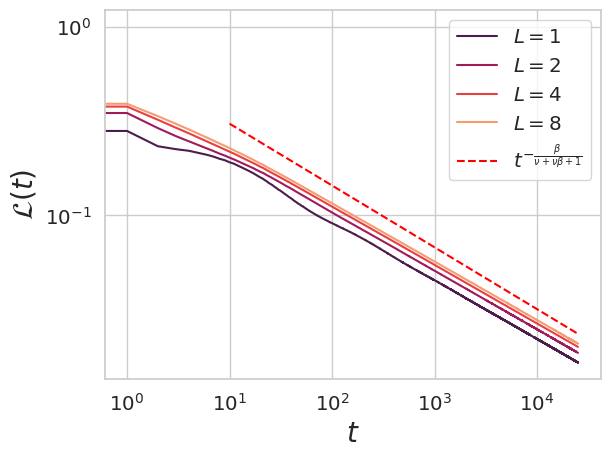

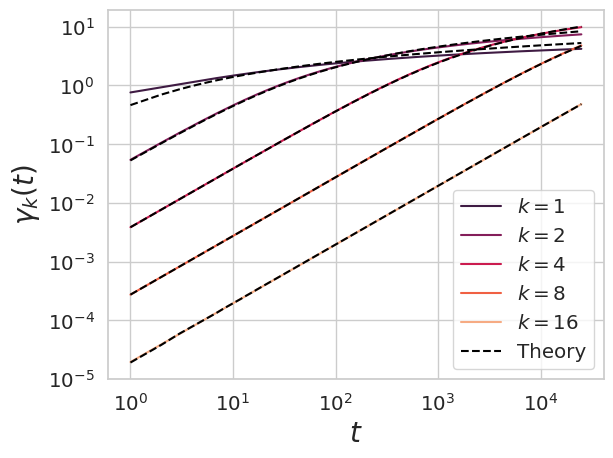

In [ ]:
sns.set_palette("rocket", n_colors=len(all_loss))

for i, loss in enumerate(all_loss):
  plt.loglog(loss, label = f'$L={Lvals[i]}$')
plt.loglog( jnp.linspace(10,T,T) , 0.65* jnp.linspace(10,T,T)**(- beta/(alpha + beta*alpha +  1)), '--', label = r'$t^{- \frac{\beta}{\nu + \nu \beta + 1}}$', color = 'red' )
plt.xlabel(f'$t$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}(t)$',fontsize = 20)
plt.legend()
plt.savefig('losses_fixed_covariance.pdf',bbox_inches='tight')
plt.show()

ks = [ 1,2,4,8, 16]
fmts = ['-', ':', '--']
sns.set_palette("rocket", n_colors=len(ks))

for j, k in enumerate(ks):
    k = k-1
    plt.loglog( jnp.linspace(1,len(eigs), len(eigs)), all_eigs[-1,:,k], color = f'C{j}',label = f'$k = {k+1}$')

ts =  jnp.linspace(1,len(eigs), len(eigs))
for k in ks:
  k = k-1
  plt.loglog(ts , jnp.log( 1.0 + 4 * eta * spec[k]**3 * w_star[k]**2 * ts  ) / spec[k] / 2.0 , '--', color = 'black' )

plt.loglog([],[],'--', color ='black', label = 'Theory')
plt.xlabel(f'$t$',fontsize = 20)
plt.ylabel(r'$\gamma_k(t)$',fontsize = 20)
plt.legend()
plt.savefig('eig_evolution_fixed_covariance.pdf',bbox_inches='tight')
plt.show()

In [ ]:
A = random.normal( random.PRNGKey(0), (M , M ) )
A = 0.5 * ( A - A.T ) / jnp.sqrt(M)

thetas = jnp.linspace(0, 0.25, 250)

Sigma = jnp.diag( spec )

print(spec**(-1.0))

Lvals = [1,2,4,8]

all_losses = []
for i, L in enumerate(Lvals):
  losses_i = []
  Gamma = L * jnp.diag( spec**(-1.0) )

  for theta in thetas:

    if theta == 0:
      O_theta = jnp.eye(len(spec))
    else:
      O_theta = jax.scipy.linalg.expm( theta * A )

    Sigma_2 = O_theta @ Sigma @ O_theta.T
    #Sigma_2 = Sigma

    Mat = jnp.eye(len(spec)) -  Gamma @ Sigma_2 / L
    v = O_theta @ w_star


    for l in range(L):
      v = Mat @ v

    losses_i += [ jnp.sum( v * ( Sigma_2 @ v ) ) ]

  all_losses += [losses_i]





[  1.          2.3784142   3.9482222   5.656854    7.476744    9.390508
  11.386036   13.454343   15.588458   17.782795   20.032763   22.334517
  24.684776   27.080708   29.519844   32.         34.519234   37.07581
  39.668148   42.29485    44.954597   47.64621    50.36859    53.120735
  55.9017     58.710625   61.546684   64.40915    67.29728    70.21042
  73.14794    76.10925    79.0938     82.101036   85.13048    88.181625
  91.254036   94.3473     97.460976  100.59467   103.748024  106.920654
 110.112236  113.32242   116.550896  119.79737   123.06154   126.34311
 129.64182   132.9574    136.2896    139.63818   143.00288   146.38353
 149.77985   153.19164   156.61868   160.0608    163.51779   166.98946
 170.47563   173.9761    177.49074   181.01933   184.56174   188.11781
 191.68738   195.27028   198.86638   202.47554   206.09761   209.73245
 213.37991   217.03993   220.71233   224.39696   228.09377   231.80257
 235.52328   239.25581   243.        246.75577   250.523     254.30159
 

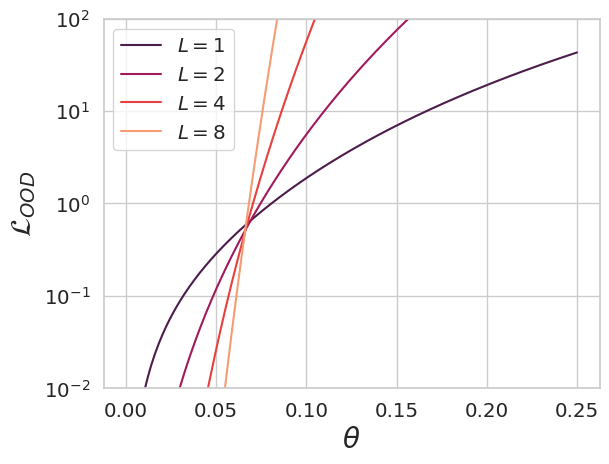

In [ ]:
for i, loss in enumerate(all_losses):
  plt.semilogy( thetas, loss, label = f'$L = {Lvals[i]}$')
plt.ylim([1e-2,1e2])
plt.legend()
plt.xlabel(r'$\theta$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}_{OOD}$',fontsize = 20)
plt.savefig('ood_loss_fixed_covariance.pdf',bbox_inches='tight')
plt.show()

In [ ]:
# wo = wy
def model_eval_decoupled_softmax_frozen_emb(params_tr, Wy , X, y, L=100, P_test = 1, beta = 100.0, qk_ln = False, norm_inputs = False):

  W_x, Wq, Wk, Wv = params_tr

  N , d = W_x.shape

  # load in the input data
  hx = jnp.einsum('ijk,lk->ijl', X, W_x)

  seq_len = X.shape[1]
  P_tr = seq_len - P_test

  # mask y data
  mask_y = np.ones( y.shape )
  mask_y[:,P_tr:] = np.zeros(( B, P_test ))

  hy = jnp.einsum('ij,k->ijk', y * mask_y , Wy) # B x P x N


  mask = np.ones((seq_len, seq_len))
  mask[:,P_tr:] = np.zeros( (seq_len , P_test ))
  mask = jnp.array(mask)


  for l in range(L):

    q = jnp.einsum('ijk,lk->ijl', hx,  Wq) / jnp.sqrt(N) # contract over N dimension
    k = jnp.einsum('ijk,lk->ijl', hx,  Wk) / jnp.sqrt(N)

    v = jnp.einsum('ijk,lk->ijl', hy,  Wv) / jnp.sqrt(N)
    A = jnp.einsum('ijk,ilk->ijl', k, q) / N   # B x P x P

    A = jnp.exp( A )

    # mask the attention
    hy = hy - beta/L * jnp.einsum('ijk,ilj->ilk', v,  jnp.einsum('ijk,jk->ijk', A, mask)  ) / P_tr

  #out = jnp.einsum('ijk,k->ij', hy, w_out) / N
  out = jnp.einsum('ijk,k->ij', hy, Wy) / N
  return out , [], []


In [ ]:
def train_model_softmax( data_params, model_params , opt_params, spec = None, w_star = None, random_rotate = True, unrestricted = False, online = True):

  d, P_tr, P_test, B = data_params

  N, L, beta, gamma = model_params

  T, lr, lamb = opt_params


  params = init_params(d, N, sigma = 0.45)
  W_x, Wy, Wq, Wk, Wv, w_out = params

  params_tr = [W_x, Wq, Wk, Wv]

  loss_fn = lambda pt, X, y: jnp.mean( ( model_eval_decoupled_softmax_frozen_emb(pt, Wy, X, y, L = L, P_test=P_test, beta = beta, qk_ln=False)[0][:,P_tr:] / gamma + y[:,P_tr:] )**2 )
  if unrestricted:
    loss_fn = lambda pt, X, y: jnp.mean( ( model_eval(pt, X, y, L = L, P_test=P_test, beta = beta, qk_ln=False)[0][:,P_tr:] / gamma + y[:,P_tr:] )**2 )
    params_tr = [ W_x, Wy, Wq, Wk, Wv, w_out ]

  loss_fn = jax.jit(loss_fn)

  reg_loss_fn = lambda pt, X, y: N * gamma**2 * loss_fn(pt, X, y) + lamb * optimizers.l2_norm(pt)**2

  opt_init, opt_update, get_params = optimizers.sgd( lr )
  #opt_state = opt_init(params)
  opt_state = opt_init(params_tr)
  loss_grad_fn = jax.jit( jax.value_and_grad(reg_loss_fn) )


  pretrain_loss = []

  if online==False:
    train_loss = []

  for t in range(T):

    if online:
      seed_t = t
    else:
      seed_t = 0

    if spec is not None:
      if random_rotate:
        X , y = sample_data_spec_rotate(spec, w_star, B, P_tr, P_test, seed = seed_t)
      else:
        X, y = sample_data_spec( spec, w_star, B, P_tr, P_test, seed = seed_t)
    else:
      X, y = sample_data(d, B, P_tr, P_test, seed = t)
    _ , grads = loss_grad_fn(get_params(opt_state), X, y)
    loss = loss_fn(get_params(opt_state), X, y)
    opt_state = opt_update(t, grads, opt_state)

    if online:
      pretrain_loss += [ loss ]
    else:
      X , y = sample_data_spec_rotate(spec, w_star, B, P_tr, P_test, seed = seed_t+1)
      test_loss = loss_fn(get_params(opt_state), X, y)
      pretrain_loss += [test_loss]
      train_loss += [ loss ]


    if t % 100 == 0:
      if online:
        sys.stdout.write(f'\r L = {L}, step {t} , loss = {loss}')
      else:
        sys.stdout.write(f'\r L = {L} , step {t} , train loss = {loss}, test loss = {test_loss}')

  if online==False:
    return pretrain_loss, train_loss

  return pretrain_loss

In [ ]:
d = 32
P_test = 64
B = 1024

#alpha = 1.25
alpha = 0.0
spec = jnp.linspace(1,d,d)**(- alpha)
spec = spec / jnp.sum(spec)

beta = 1.75
w_star = jnp.sqrt( jnp.linspace(1, d, d)**(-alpha*beta-1.0) / spec )
w_star = w_star / jnp.sqrt( jnp.sum( w_star**2 * spec ) )

T = 25000
lr = 0.1

lamb = 0.0
beta_model = 1.0

#N = int(1.25 * d)
#N = 100
N = d

params = init_params(d, N)

gamma = 1.0

all_losses = []

P_trs = [ 32 ]
Lvals = [1,2,4]


for i, P_tr in enumerate(P_trs):
  print("")
  print(f"P = {P_tr}")
  all_loss_i = []
  for j, L in enumerate(Lvals):
    data_params = [d, P_tr, P_test, B]
    model_params = [ N , L, beta_model , gamma]
    opt_params = [T, lr, lamb]

    pretrain_loss = train_model_softmax(data_params, model_params, opt_params, spec = spec, w_star = w_star, random_rotate=False)
    all_loss_i += [pretrain_loss]
  all_losses += [all_loss_i]



P = 32
 L = 4, step 24900 , loss = nan

In [ ]:
all_losses = jnp.array(all_losses)

final_losses = all_losses[:,:,-10:-1].mean(axis=-1)


IndexError: Too many indices: 1-dimensional array indexed with 3 regular indices.

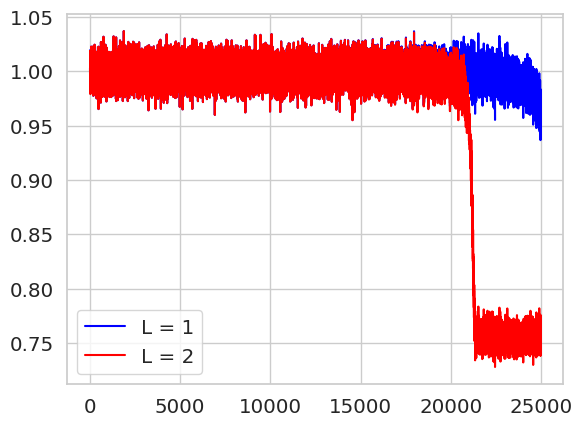

In [ ]:
colors = ['blue','red']
for i, L in enumerate(Lvals[:2]):
  plt.plot(all_loss_i[i], color = colors[i], label = f'L = {L}')
plt.legend()
plt.show()


### Linear Attention Dynamics

In [ ]:

def init_params(d, N, sigma = 0.4):

  W_x = jnp.sqrt(2.0) * sigma * jnp.eye(d)
  W_y = jnp.ones(N) / jnp.sqrt(N)
  #W_y = jnp.ones(N)
  Wq = sigma * jnp.eye(N)

  Wk = 1.0 * Wq

  Wv = sigma * jnp.eye(N) * jnp.sqrt(d)

  w_out = 1.0 * W_y

  params = [ W_x, W_y, Wq , Wk, Wv, w_out]
  return params



# wo = wy
def model_eval_decoupled_frozen_emb(params_tr, Wy , X, y, L=100, P_test = 1, beta = 1.0, qk_ln = False, norm_inputs = False):

  W_x, Wq, Wk, Wv = params_tr

  N , d = W_x.shape

  # load in the input data
  hx = jnp.einsum('ijk,lk->ijl', X, W_x)

  seq_len = X.shape[1]
  P_tr = seq_len - P_test

  # mask y data
  mask_y = np.ones( y.shape )
  mask_y[:,P_tr:] = np.zeros(( B, P_test ))

  hy = jnp.einsum('ij,k->ijk', y * mask_y , Wy) # B x P x N


  mask = np.ones((seq_len, seq_len))
  mask[:,P_tr:] = np.zeros( (seq_len , P_test ))
  mask = jnp.array(mask)


  for l in range(L):

    q = jnp.einsum('ijk,lk->ijl', hx,  Wq)   # contract over N dimension
    k = jnp.einsum('ijk,lk->ijl', hx,  Wk)

    v = jnp.einsum('ijk,lk->ijl', hy,  Wv)
    A = jnp.einsum('ijk,ilk->ijl', k, q)   # B x P x P


    # mask the attention
    hy = hy - beta / L * jnp.einsum('ijk,ilj->ilk', v, jnp.einsum('ijk,jk->ijk', A, mask)  ) / P_tr / jnp.sqrt(d)

  out = jnp.einsum('ijk,k->ij', hy, Wy)
  #out = jnp.einsum('ijk,k->ij', hy, Wy)

  return out , [], []


def sample_data_gauss_isotropic(d, B, P_tr, P_te, seed = 0):

  X = random.normal(random.PRNGKey(2*seed), (B, P_tr + P_te , d))
  betas = random.normal( random.PRNGKey(2*seed + 1), (B,d) )
  y = jnp.einsum('ijk,ik->ij', X, betas) / jnp.sqrt(d) # B x (P + P_test)
  return X, y


def train_model_isotropic( data_params, model_params , opt_params, spec = None, w_star = None, random_rotate = True, unrestricted = False, online = True):

  d, P_tr, P_test, B = data_params

  N, L, beta, gamma = model_params

  T, lr, lamb = opt_params

  params = init_params(d, N)
  W_x, Wy, Wq, Wk, Wv, w_out = params

  params_tr = [W_x, Wq, Wk, Wv]

  loss_fn = lambda pt, X, y: jnp.mean( ( model_eval_decoupled_frozen_emb(pt, Wy, X, y, L = L, P_test=P_test, beta = beta, qk_ln=False)[0][:,P_tr:] / gamma + y[:,P_tr:] )**2 )
  loss_fn = jax.jit(loss_fn)

  reg_loss_fn = lambda pt, X, y:  loss_fn(pt, X, y) + lamb * optimizers.l2_norm(pt)**2

  opt_init, opt_update, get_params = optimizers.sgd( lr )
  #opt_state = opt_init(params)
  opt_state = opt_init(params_tr)
  loss_grad_fn = jax.jit( jax.value_and_grad(reg_loss_fn) )


  pretrain_loss = []
  weight_norms = []

  if online==False:
    train_loss = []

  for t in range(T):

    if online:
      seed_t = t
    else:
      seed_t = 0

    X, y = sample_data_gauss_isotropic(d, B, P_tr, P_test, seed = seed_t+1)
    _ , grads = loss_grad_fn(get_params(opt_state), X, y)
    loss = loss_fn(get_params(opt_state), X, y)
    opt_state = opt_update(t, grads, opt_state)

    if online:
      pretrain_loss += [ loss ]
    else:
      X , y = sample_data_gauss_isotropic(d, B, P_tr, P_test, seed = seed_t+1)
      test_loss = loss_fn(get_params(opt_state), X, y)
      pretrain_loss += [test_loss]
      train_loss += [ loss ]


    [W_x, Wq, Wk, Wv] = get_params(opt_state)

    weight_norms += [  [ jnp.mean( jnp.diag(W_x) ), jnp.mean(jnp.diag(Wq)), jnp.mean(jnp.diag(Wk)), jnp.dot( Wy, Wv @ Wy ) ]  ]


    if t % 100 == 0:
      if online:
        sys.stdout.write(f'\r step {t} , loss = {loss}')
      else:
        sys.stdout.write(f'\r step {t} , train loss = {loss}, test loss = {test_loss}')

  if online==False:
    return pretrain_loss, train_loss

  return pretrain_loss, weight_norms

In [ ]:

def reduced_theory_linear_att_isotropic( L, alpha, lamb_grid, eta, T, sigma=0.4 ):

  w = sigma

  lamb_p = (1 + 1.0/jnp.sqrt(alpha))**2
  lamb_m = (1 - 1.0/jnp.sqrt(alpha))**2
  bulk = alpha/(2*jnp.pi * lamb_grid) * jnp.sqrt( (lamb_p - lamb_grid) * (lamb_grid - lamb_m ) ) * ( lamb_grid < lamb_p)* ( lamb_grid > lamb_m)
  plt.plot(lamb_grid, bulk)
  plt.show()

  dlamb = ( lamb_grid[-1] - lamb_grid[0] ) / len(lamb_grid)


  loss_fn = jit( lambda w: jnp.dot( bulk * dlamb , (1.0 - 1.0 / L * w**5 * lamb_grid )**(2*L) ) + (1.0-alpha) * (alpha < 1.0)  )
  grad_fn = jit(grad(loss_fn))
  losses = []
  ws = []
  for t in range(T):

    loss_t = loss_fn( w )
    sys.stdout.write(f'\r t = {t},  loss = {loss_t} , w = {w}')
    losses += [ loss_t ]
    ws += [w]
    # int rho(lambda) (1 - 1/L * gamma *  lamb )
    w += - 1 / 5.0 * eta * grad_fn(w)
  return losses, ws


def reduced_theory_four_var_linear_att_isotropic( L, alpha, lamb_grid, eta, T, sigma=0.4 ):

  # Wx, Wq, Wk, Wv
  ws = [ jnp.sqrt(2)*sigma, sigma, sigma, sigma ]

  lamb_p = (1 + 1.0/jnp.sqrt(alpha))**2
  lamb_m = (1 - 1.0/jnp.sqrt(alpha))**2
  bulk = alpha/(2*jnp.pi * lamb_grid) * jnp.sqrt( (lamb_p - lamb_grid) * (lamb_grid - lamb_m ) ) * ( lamb_grid < lamb_p)* ( lamb_grid > lamb_m)
  plt.plot(lamb_grid, bulk)
  plt.show()

  dlamb = ( lamb_grid[-1] - lamb_grid[0] ) / len(lamb_grid)



  loss_fn = jit( lambda ws: jnp.dot( bulk * dlamb , (1.0 - 1.0 / L * ws[0]**2 * ws[1]*ws[2]*ws[3]* lamb_grid )**(2*L) ) + (1.0-alpha) * (alpha < 1.0)  )
  grad_fn = jit(grad(loss_fn))
  losses = []
  all_ws = []
  for t in range(T):

    loss_t = loss_fn( ws )
    sys.stdout.write(f'\r t = {t},  loss = {loss_t} , gamma = { ws[0]**2 * ws[1] * ws[2] * ws[3] }')
    losses += [ loss_t ]
    all_ws += [ ws ]
    # int rho(lambda) (1 - 1/L * gamma *  lamb )
    gs = grad_fn(ws)
    ws = [w - eta * gs[i] for i, w in enumerate(ws)]
  return losses, all_ws

In [ ]:
d = 128
P_tr = 128
P_test = 32
B = 1024

spec = jnp.ones(d)
spec = spec

w_star = jnp.ones(d) / jnp.sqrt(d)

T = 1000
#T = 2000
lr =  0.1

lamb = 0.0
beta_model = 1.0

N = d

params = init_params(d, N)

gamma = 1.0

Lvals = [1,2,4,8]

data_params = [d, P_tr, P_test, B]
opt_params = [T, lr * jnp.sqrt(d), lamb]

all_losses = []
all_weight_norms = []

for i, L in enumerate(Lvals):
  print("")
  print(f"L = {L}")
  model_params = [ N , L, beta_model , gamma ]
  pretrain_loss, weight_norms = train_model_isotropic(data_params, model_params, opt_params, spec = spec, w_star = w_star, random_rotate=False)
  all_losses += [pretrain_loss]
  all_weight_norms += [weight_norms]


L = 1
 step 900 , loss = 0.5038360953330994
L = 2
 step 900 , loss = 0.37666410207748413
L = 4
 step 900 , loss = 0.27549833059310913
L = 8
 step 900 , loss = 0.19848255813121796

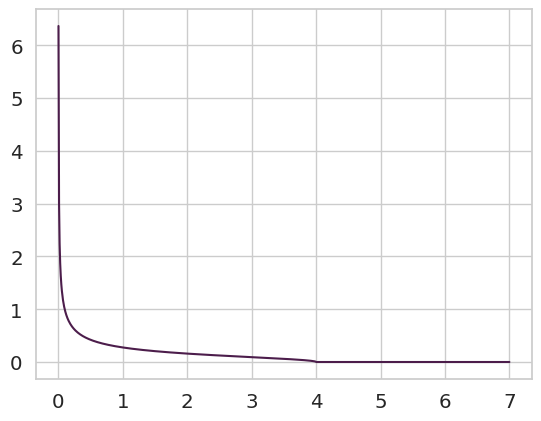

 t = 999,  loss = 0.5015178918838501 , gamma = 0.5000011920928955

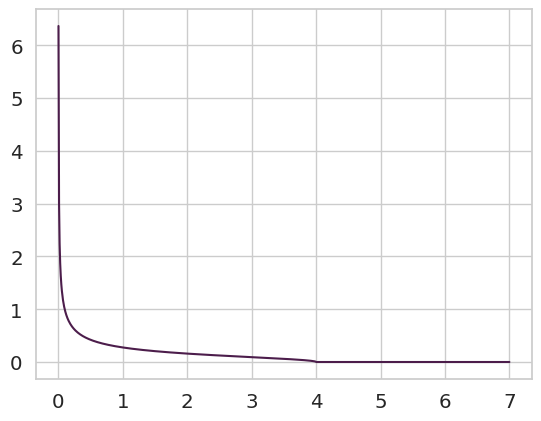

 t = 999,  loss = 0.37664994597435 , gamma = 1.000004768371582

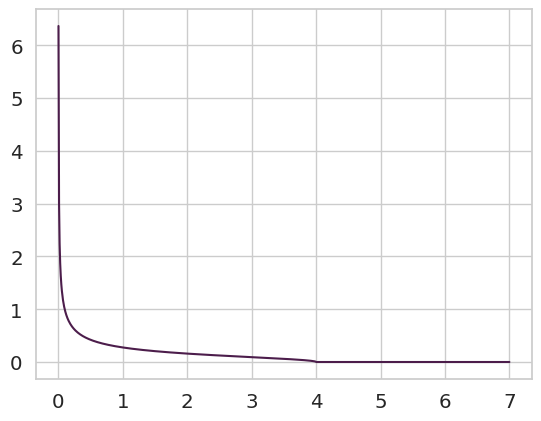

 t = 999,  loss = 0.27516573667526245 , gamma = 2.000013828277588

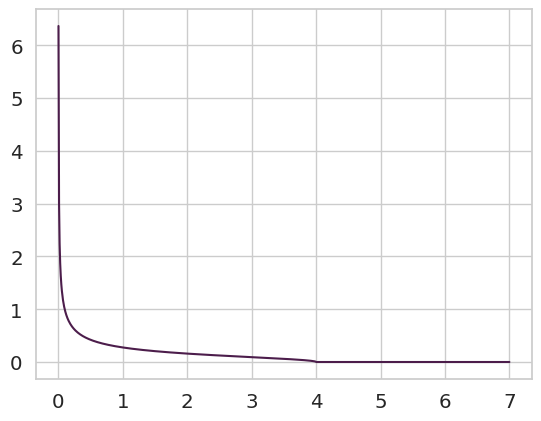

 t = 999,  loss = 0.19810763001441956 , gamma = 4.000046253204346

In [ ]:
lamb_grid = jnp.linspace(0.0025, 7, 800)

"""
losses_th = []
ws_th = []

for i, L in enumerate(Lvals):
  loss_i, ws = reduced_theory_linear_att_isotropic( L, 1.0*P_tr/d, lamb_grid, eta=lr, T = 1000)

  losses_th += [loss_i]
  ws_th += [ws]
"""

losses_th = []
all_ws = []

for i, L in enumerate(Lvals):
  loss_i, ws_i = reduced_theory_four_var_linear_att_isotropic( L, 1.0*P_tr/d, lamb_grid, eta=lr / jnp.sqrt(d), T = 1000)

  losses_th += [loss_i]
  all_ws += [ ws_i ]

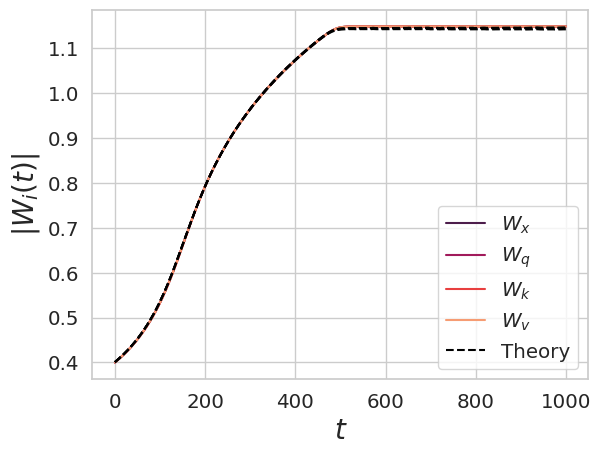

In [ ]:
sns.set_palette("rocket", n_colors=4)

labels  = [r'$W_x$', r'$W_q$', r'$W_k$', r'$W_v$']

ws_final = jnp.array(all_ws[-1])
for i in range(4):
  if i == 0:
    plt.plot( ws_final[ :,i] / jnp.sqrt(2.0) , label = labels[i] )
  else:
    plt.plot( ws_final[ :,i] , label = labels[i] )


ws_expt_final = jnp.array(all_weight_norms[-1])

for i in range(4):
  if i == 0:
    plt.plot( ws_expt_final[ :,i] / jnp.sqrt(2.0) ,  '--', color = 'black' )
  elif i==3:
    plt.plot( ws_expt_final[ :,i]/jnp.sqrt(d), '--',color = 'black' )
  else:
    plt.plot( ws_expt_final[ :,i], '--',color = 'black' )

plt.plot([],[], '--', color ='black', label = 'Theory')
plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel(r'$|W_i(t)|$',fontsize = 20)
plt.legend()
plt.savefig('weight_norm_dynamics.pdf',bbox_inches = 'tight')
plt.show()

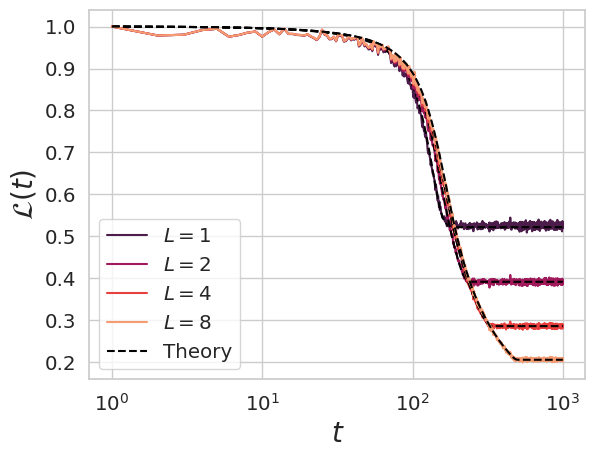

In [ ]:
for i, loss in enumerate(all_losses):
  plt.semilogx(jnp.linspace(1,T,T), jnp.array(loss) / loss[0], label = f'$L = {Lvals[i]}$')
  plt.semilogx(jnp.linspace(1,T,T), jnp.array(losses_th[i])/losses_th[i][0], '--',color = 'black')

plt.semilogx([],[],'--',color ='black', label = 'Theory')
plt.xlabel(r'$t$',fontsize =20)
plt.ylabel(r'$\mathcal{L}(t)$',fontsize= 20)
plt.legend()
plt.savefig('isotropic_theory_vs_expt.pdf',bbox_inches = 'tight')
plt.show()



In [ ]:
print([loss[-1] for loss in all_losses])
print(  [loss[-1] for loss in losses_th] )


[Array(0.32773373, dtype=float32), Array(0.18518972, dtype=float32), Array(0.08530601, dtype=float32), Array(0.03067525, dtype=float32)]
[Array(0.5030671, dtype=float32), Array(0.29894197, dtype=float32), Array(0.1400542, dtype=float32), Array(0.04676682, dtype=float32)]


In [ ]:
def reduced_theory_four_var_linear_att_spec(spec, w_star, L, eta, T, sigma=0.4 ):

  # Wx, Wq, Wk, Wv
  ws = [ jnp.sqrt(2)*sigma, sigma, sigma, sigma ]

  @jit
  def loss_fn(ws):

    loss = jnp.sum( spec * (1.0 - 1.0 / L * ws[0]**2 * ws[1]*ws[2]*ws[3]* lamb_grid )**(2*L) * w_star**2 )
    return loss

  grad_fn = jit(grad(loss_fn))
  losses = []
  all_ws = []
  for t in range(T):

    loss_t = loss_fn( ws )
    sys.stdout.write(f'\r t = {t},  loss = {loss_t} , gamma = { ws[0]**2 * ws[1] * ws[2] * ws[3] }')
    losses += [ loss_t ]
    all_ws += [ ws ]
    # int rho(lambda) (1 - 1/L * gamma *  lamb )
    gs = grad_fn(ws)
    ws = [w - eta * gs[i] for i, w in enumerate(ws)]
  return losses, all_ws



In [ ]:

def init_params_dim_free(d, N, sigma = 0.4):

  W_x = jnp.sqrt(2.0) * sigma * jnp.eye(d)
  W_y = jnp.ones(N) / jnp.sqrt(N)
  #W_y = jnp.ones(N)
  Wq = sigma * jnp.eye(N)

  Wk = 1.0 * Wq

  Wv = sigma * jnp.eye(N) * jnp.sqrt(N)

  w_out = 1.0 * W_y

  params = [ W_x, W_y, Wq , Wk, Wv, w_out]
  return params



# wo = wy
def model_eval_decoupled_frozen_emb_dim_free(params_tr, Wy , X, y, L=100, P_test = 1, beta = 1.0, qk_ln = False, norm_inputs = False):

  W_x, Wq, Wk, Wv = params_tr

  N , d = W_x.shape

  # load in the input data
  hx = jnp.einsum('ijk,lk->ijl', X, W_x)

  seq_len = X.shape[1]
  P_tr = seq_len - P_test

  # mask y data
  mask_y = np.ones( y.shape )
  mask_y[:,P_tr:] = np.zeros(( B, P_test ))

  hy = jnp.einsum('ij,k->ijk', y * mask_y , Wy) # B x P x N


  mask = np.ones((seq_len, seq_len))
  mask[:,P_tr:] = np.zeros( (seq_len , P_test ))
  mask = jnp.array(mask)


  for l in range(L):

    q = jnp.einsum('ijk,lk->ijl', hx,  Wq)   # contract over N dimension
    k = jnp.einsum('ijk,lk->ijl', hx,  Wk)

    v = jnp.einsum('ijk,lk->ijl', hy,  Wv)
    A = jnp.einsum('ijk,ilk->ijl', k, q)   # B x P x P


    # mask the attention
    hy = hy - beta / L * jnp.einsum('ijk,ilj->ilk', v, jnp.einsum('ijk,jk->ijk', A, mask)  ) / P_tr

  out = jnp.einsum('ijk,k->ij', hy, Wy)
  #out = jnp.einsum('ijk,k->ij', hy, Wy)

  return out , [], []


def sample_data_spec_rotate(spec, w_star, B, P_tr, P_te, seed = 0):

  d = spec.shape[0]

  O = jnp.linalg.qr( random.normal(random.PRNGKey(3*seed), (B, d, d)) )[0]

  X = random.normal(random.PRNGKey(3*seed+1), (B, P_tr+P_te, d))
  X = jnp.einsum('ijk,k->ijk', X, spec**(0.5))
  OX = jnp.einsum('ijk,ilk->ilj', O, X)


  bernoulli = random.bernoulli(random.PRNGKey(3*seed+2), shape=(B,d))
  bernoulli = 2*bernoulli - 1.0
  w_sign = w_star[jnp.newaxis,:] * bernoulli
  #betas = jnp.einsum('ijk,ik->ij', O, w_sign)
  #y = jnp.einsum('ijk,ik->ij', OX, betas)  # B x (P + P_test)
  y = jnp.einsum('ijk,ik->ij', X, w_sign)
  return OX, y


def train_model_dim_free( data_params, model_params , opt_params, spec = None, w_star = None, random_rotate = True, unrestricted = False, online = True):

  d, P_tr, P_test, B = data_params

  N, L, beta, gamma = model_params

  T, lr, lamb = opt_params

  params = init_params_dim_free(d, N, sigma = 0.45)
  W_x, Wy, Wq, Wk, Wv, w_out = params

  params_tr = [W_x, Wq, Wk, Wv]

  loss_fn = lambda pt, X, y: jnp.mean( ( model_eval_decoupled_frozen_emb_dim_free(pt, Wy, X, y, L = L, P_test=P_test, beta = beta, qk_ln=False)[0][:,P_tr:] / gamma + y[:,P_tr:] )**2 )
  loss_fn = jax.jit(loss_fn)

  reg_loss_fn = lambda pt, X, y:  loss_fn(pt, X, y) + lamb * optimizers.l2_norm(pt)**2

  opt_init, opt_update, get_params = optimizers.sgd( lr )
  #opt_state = opt_init(params)
  opt_state = opt_init(params_tr)
  loss_grad_fn = jax.jit( jax.value_and_grad(reg_loss_fn) )


  pretrain_loss = []
  weight_norms = []

  if online==False:
    train_loss = []

  for t in range(T):

    if online:
      seed_t = t
    else:
      seed_t = 0

    X, y = sample_data_spec_rotate(spec, w_star, B, P_tr, P_test, seed = seed_t+1)
    _ , grads = loss_grad_fn(get_params(opt_state), X, y)
    loss = loss_fn(get_params(opt_state), X, y)
    opt_state = opt_update(t, grads, opt_state)

    if online:
      pretrain_loss += [ loss ]
    else:
      X , y = sample_data_spec_rotate(spec, w_star, B, P_tr, P_test, seed = seed_t+1)
      test_loss = loss_fn(get_params(opt_state), X, y)
      pretrain_loss += [test_loss]
      train_loss += [ loss ]


    [W_x, Wq, Wk, Wv] = get_params(opt_state)

    weight_norms += [  [ jnp.mean( jnp.diag(W_x) ), jnp.mean(jnp.diag(Wq)), jnp.mean(jnp.diag(Wk)), jnp.dot( Wy, Wv @ Wy ) ]  ]


    if t % 1 == 0:
      if online:
        sys.stdout.write(f'\r step {t} , loss = {loss}')
      else:
        sys.stdout.write(f'\r step {t} , train loss = {loss}, test loss = {test_loss}')

  if online==False:
    return pretrain_loss, train_loss

  return pretrain_loss, weight_norms

In [ ]:
d = 80
P_tr = 256
P_test = 32
B = 512

M = d

alpha = 1.25
beta = 1.2

# N^{- alpha * beta} + L^{-beta} ,   N^{-alpha beta} = L^{-beta}


spec = jnp.linspace(1,M,M)**(-alpha)
w_star = jnp.linspace(1,M,M)**(- (alpha*beta+1 - alpha)*0.5 )
w_star = w_star / jnp.sqrt( jnp.sum(w_star**2 * spec)  )


print(" sum of variance ")
print(jnp.sum(w_star**2*spec))

T = 1000
#T = 2000
lr =  0.125

lamb = 0.0
beta_model = 1.0

N = d

params = init_params_dim_free(d, N)

gamma = 1.0

Lvals = [1,2,4,8,16]

data_params = [d, P_tr, P_test, B]
opt_params = [T, lr * jnp.sqrt(d), lamb]

all_losses = []
all_weight_norms = []

for i, L in enumerate(Lvals):
  print("")
  print(f"L = {L}")
  model_params = [ N , L, beta_model , gamma ]
  pretrain_loss, weight_norms = train_model_dim_free(data_params, model_params, opt_params, spec = spec, w_star = w_star, random_rotate=True)
  all_losses += [pretrain_loss]
  all_weight_norms += [weight_norms]

 sum of variance 
1.0000002

L = 1
 step 999 , loss = 0.13522198796272278
L = 2
 step 999 , loss = 0.06861274689435959
L = 4
 step 999 , loss = 0.030132964253425598
L = 8
 step 999 , loss = 0.013577645644545555
L = 16
 step 999 , loss = 0.007900882512331009

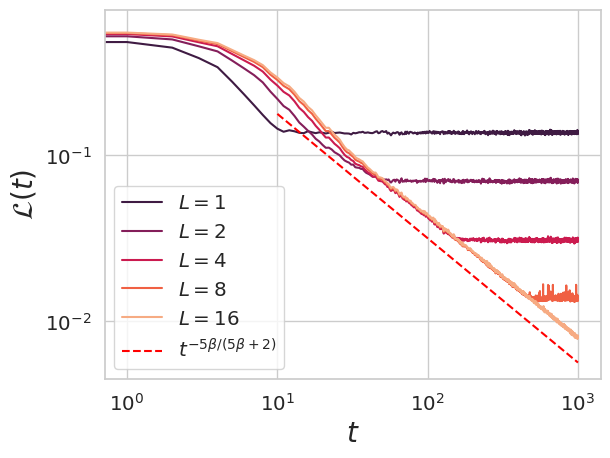

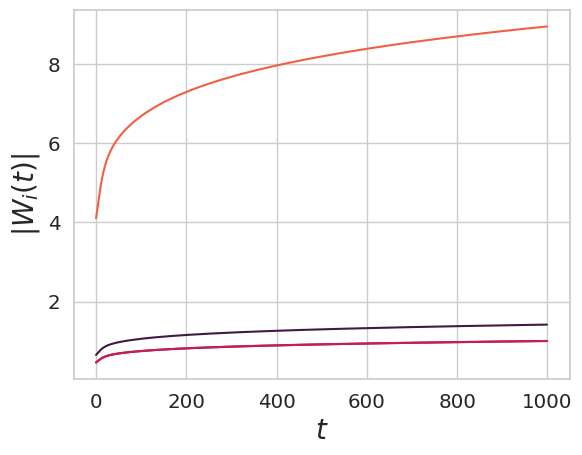

/tmp/ipython-input-1920999621.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


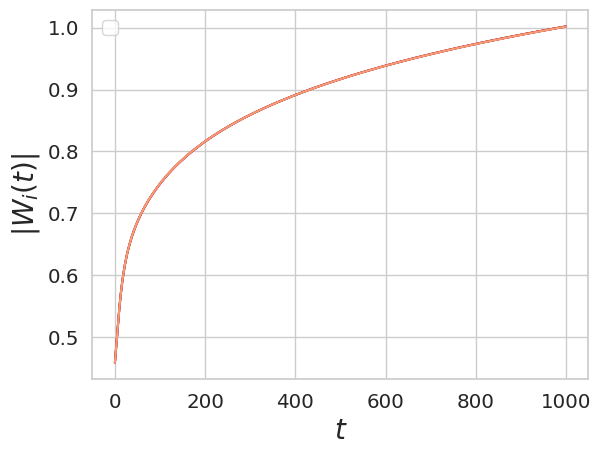

In [ ]:
sns.set_palette("rocket", n_colors=len(all_losses))

for i, loss in enumerate(all_losses):
  plt.loglog(loss, label = f'$L = {Lvals[i]}$')
plt.loglog( jnp.linspace(10,T,T), jnp.linspace(10,T,T)**(-5*beta/(5*beta+2)), '--', color = 'red', label = r'$t^{- 5\beta/(5\beta+2)}$')
plt.xlabel(r'$t$',fontsize =20)
plt.ylabel(r'$\mathcal{L}(t)$',fontsize = 20)
plt.legend()
plt.savefig('dim_free_theory_weight_decoupled_vs_expt.pdf',bbox_inches = 'tight')
plt.show()

weight_arr = jnp.array(all_weight_norms[-1])
for i in range(4):
  plt.plot(weight_arr[:,i])
plt.xlabel(r'$t$',fontsize =20)
plt.ylabel(r'$|W_i(t)|$',fontsize = 20)
plt.show()


sns.set_palette("rocket", n_colors=4)

ws_expt_final = weight_arr

for i in range(4):
  if i == 0:
    plt.plot( ws_expt_final[ :,i] / jnp.sqrt(2.0)  )
  elif i==3:
    plt.plot( ws_expt_final[ :,i]/jnp.sqrt(d) )
  else:
    plt.plot( ws_expt_final[ :,i])

plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel(r'$|W_i(t)|$',fontsize = 20)
plt.legend()
#plt.savefig('weight_norm_dynamics.pdf',bbox_inches = 'tight')
plt.show()

In [ ]:
X, y = sample_data_spec_rotate(spec, w_star, B, P_tr, P_test, seed = 0)

print(jnp.mean(y**2))

1.0028175


### Decoupled Layers

In [ ]:
def reduced_Gamma_decoupled_depth_structured_SGD_dynamics(spec, beta_bar, N, L, B, K, P, sigma = 0.0, eta = 0.01, T=100, lamb = 1e-3, rotate=True, ctx_sample=True):

  d = len(spec)
  Gamma = [ jnp.zeros((N,N)) for l in range(L) ]

  #Gamma = jnp.zeros((d,d))


  #A = random.normal(random.PRNGKey(0), (N, d))

  A = np.zeros((N,d))
  m = min(N,d)
  A[:m,:m] += np.eye(m) * jnp.sqrt(N)
  A = jnp.array(A)

  losses = []

  @jax.jit
  def compute_loss(Gamma, A, Os_t, Sigmas_t, betas_t):

    batch = Sigmas_t.shape[0]
    dim = Sigmas_t.shape[1]

    #A_G_A = Gamma
    vs = 1.0 * betas_t
    identity = jnp.einsum('i,jk->ijk', jnp.ones(batch), jnp.eye(dim))
    #M = jnp.einsum('i,jk->ijk', jnp.ones(batch), jnp.eye(dim))
    #M = M - 1/L * jnp.einsum('jk,ikl->ijl', A_G_A, Sigmas_t)

    for l in range(L):
      A_G_A = 1/N * A.T @ Gamma[l] @ A
      M = identity - 1/L * jnp.einsum('jk,ikl->ijl', A_G_A, Sigmas_t)
      vs = jnp.einsum('ijk,ik->ij', M, vs)


    Ov = jnp.einsum('ijk,ij->ik', Os_t, vs) # O.T @ v
    return jnp.einsum('ik,ik,k->', Ov, Ov, spec ) / batch


  grad_loss = jit(grad(compute_loss, 0))

  losses = []
  var_eigs = []
  mean_eigs = [ ]

  get_O = jax.jit( lambda X: jnp.linalg.qr(X)[0] )
  for t in range(T):

    #### FINISH THIS

    d = spec.shape[0]


    #betas = random.normal( random.PRNGKey(2*seed + 1), (B,d) )

    O = get_O( random.normal(random.PRNGKey(3*t+1), (B, d, d)) )
    #O = jnp.linalg.qr( random.normal(random.PRNGKey(3*t+1), (B, d, d)) )[0]

    if ctx_sample:
      X = random.normal(random.PRNGKey(3*t), (B, P, d))
      X = jnp.einsum('ijk,k->ijk', X, spec**(0.5))
      OX = jnp.einsum('ijk,ilk->ilj', O, X)
      Sigma_c = jnp.einsum('ijk,ijl->ikl', OX, OX) / P # O Lambda_hat O^T
    else:
      Sigma_c = jnp.einsum('ijk,ilk,k->ijl', O, O, spec)

    bernoulli = random.bernoulli(random.PRNGKey(3*t+2), shape=(B,d))
    bernoulli = 2*bernoulli - 1.0
    w_sign = w_star[jnp.newaxis,:] * bernoulli

    betas = jnp.einsum('ijk,ik->ij', O, w_sign) # O beta_bar


    loss_t = compute_loss( Gamma, A, O, Sigma_c, betas)
    losses += [loss_t]

    grads =  grad_loss(Gamma, A, O, Sigma_c, betas)
    Gamma = [ Gamma[l] - eta * L * grads[l] for l in range(L) ]

    eigs = jnp.linalg.eigvalsh( A.T @ Gamma[0] @ A / N )

    var_eigs_t = ( jnp.mean( eigs**2 ) - jnp.mean(eigs)**2 ) / jnp.mean(eigs)**2
    mean_eigs += [jnp.mean(eigs)]
    sys.stdout.write(f'\r step = {t}  |  loss = {loss_t} | var_eigs = {var_eigs_t}')
    var_eigs += [var_eigs_t]

  return losses, mean_eigs, var_eigs

In [ ]:
M = 128
K = 32
B = 256
P = 512

Nvals = [ 16, 32, 64, 128, 256 ]

all_loss = []
T = 5000

alpha = 1.25
beta = 0.75

# N^{- alpha * beta} + L^{-beta} ,   N^{-alpha beta} = L^{-beta}


spec = jnp.linspace(1,M,M)**(-alpha)
w_star = jnp.linspace(1,M,M)**(- (alpha*beta+1 - alpha)*0.5 )
w_star= w_star / jnp.sqrt( jnp.sum(w_star**2 * spec)  )



In [ ]:
N = 128
Lvals_fix = [1,2,4,8]
all_loss_lin_scale = []
#eta = 0.075

eta = 4.0
T = 10000

for i, L in enumerate(Lvals_fix):
  print(f'L = {L}')
  #L = int( N/8.0 )
  losses, mean_eigs, var_eigs = reduced_Gamma_decoupled_depth_structured_SGD_dynamics(spec, w_star, N, L, B, K, P, T = T, eta = eta, ctx_sample=False, lamb = 1e-12)
  all_loss_lin_scale += [losses]

L = 1
 step = 2452  |  loss = 0.23942025005817413 | var_eigs = 0.008750996552407742

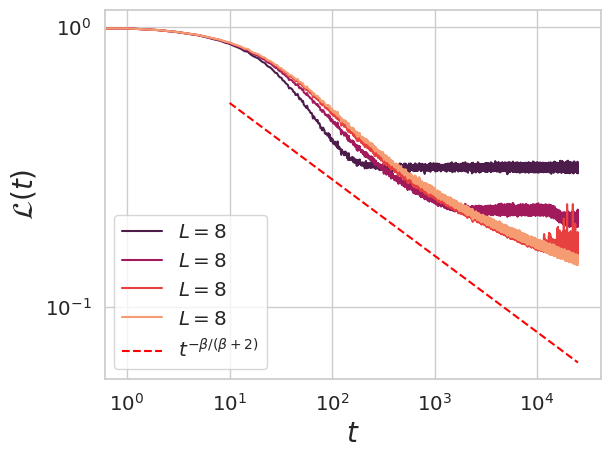

In [ ]:
sns.set_palette("rocket", n_colors=4)
for i, loss in enumerate(all_loss_lin_scale):
  plt.loglog(loss, label = f'$L = {L}$')
plt.loglog( jnp.linspace(10,T,T),  jnp.linspace(10,T,T)**(- beta/(beta + 2)) ,'--', color = 'red', label = r'$t^{-\beta/(\beta + 2)}$')
plt.legend()
plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}(t)$',fontsize = 20)
plt.savefig(r'gamma_decoupled_layers_dynamics.pdf',bbox_inches = 'tight')
plt.show()

In [ ]:
#M = 2048
M = 64

alpha = 1.5
beta = 0.8

spec = jnp.linspace(1,M,M)**(-alpha)
w_star = jnp.linspace(1,M,M)**(- (alpha*beta+1 - alpha)*0.5 )

w_star= w_star / jnp.sqrt( jnp.sum(w_star**2 * spec)  )



def loss_fn_decoupled(gammas, spec, w_star, lamb = 0.0):
  L = len(gammas)

  decay = jnp.log( 1.0 - 1.0/L * jnp.outer(gammas, spec) ).sum(axis=0)
  decay = jnp.exp( decay )
  return jnp.einsum('ij,j->i', decay, spec * w_star**2 )

In [ ]:
def pretrain_dynamics_decoupled(spec, w_star, beta0=1.0, L=4, T=100, eta = 0.05, w0=0.5):



  @jit
  def loss_fn_decoupled(gammas):
    L = len(gammas)

    decay = jnp.ones(len(spec))
    for l in range(L):
      decay = ( 1.0 - 1.0/L * gammas[l]* spec) * decay
    return jnp.sum( decay**2 *  spec * w_star**2 )

  grad_fn = jit(grad(loss_fn_decoupled))
  gammas = jnp.zeros(L)

  losses = []
  all_gammas = []
  for t in range(T):
    losses += [loss_fn_decoupled(gammas)]
    all_gammas += [gammas]
    grads = grad_fn(gammas)
    gammas = jnp.array([ gammas[i] - L * eta * grads[i] for i in range(L) ])

  return losses, all_gammas


In [ ]:
Lvals = [1,2,4,8]
all_losses = []
all_all_gammas = []
for i, L in enumerate(Lvals):
  losses, all_gammas = pretrain_dynamics_decoupled(spec, w_star, L=L, T= 5000, eta = 0.2)
  all_losses += [losses]

  all_all_gammas += [all_gammas]

[1.0000002  0.61766887 0.4183113  ... 0.20110309 0.20110309 0.20110309]
[1.0000002  0.63984764 0.4832005  ... 0.12141225 0.12141225 0.12141225]
[1.0000002  0.6495604  0.5085494  ... 0.06453021 0.06453021 0.06453021]
[1.0000002  0.6541305  0.51993704 ... 0.04158799 0.0415854  0.04158282]


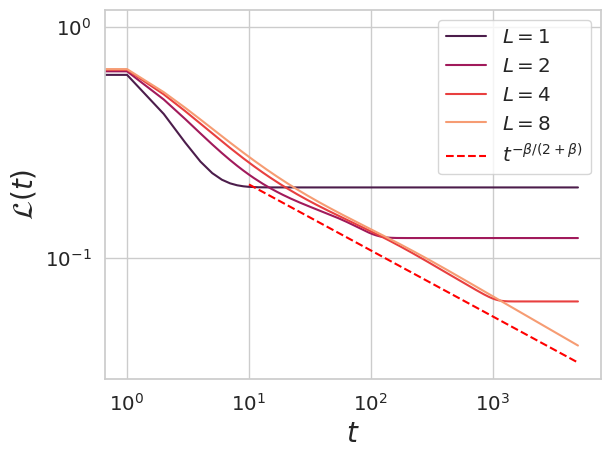

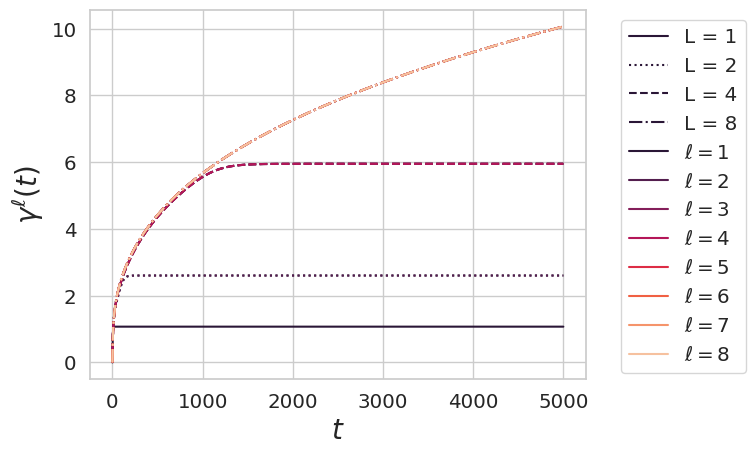

In [ ]:
sns.set_palette("rocket", n_colors=len(Lvals))
T = 5000
for i, loss in enumerate(all_losses):
  print(jnp.array(loss))
  plt.loglog(loss,label = f'$L = {Lvals[i]}$')
plt.loglog(jnp.linspace(10,T,T), 0.4*jnp.linspace(10,T,T)**(- beta / (beta+2)) , '--', color = 'red',label = r'$t^{-\beta/(2+\beta)}$')
plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel(r'$\mathcal{L}(t)$',fontsize = 20)
plt.legend()
plt.savefig('decoupled_layers_powerlaw_dynamics.pdf',bbox_inches = 'tight')
plt.show()

linestyles= ['-', ':', '--', '-.']
sns.set_palette("rocket", n_colors= Lvals[-1])

for i, all_gammas in enumerate(all_all_gammas):
  all_gammas=jnp.array(all_gammas)

  for j, gamma in enumerate(all_gammas.T):
    plt.plot(gamma, linestyles[i], color = f'C{j}')

for i, L in enumerate(Lvals):
  plt.plot([],[], linestyles[i], color = 'C0', label = f'L = {L}')
for k in range(Lvals[-1]):
  plt.plot([],[], color = f'C{k}',label = r'$\ell = %d$' % (k+1))
plt.xlabel(r'$t$',fontsize =20)
plt.ylabel(r'$\gamma^\ell(t)$',fontsize = 20)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('gamma_ells_balanced_powerlaw.pdf',bbox_inches = 'tight')
plt.show()

In [ ]:
def pretrain_dynamics_decoupled_noisy(spec, w_star, beta0=1.0, L=4, T=100, eta = 0.05, w0=0.5, sigma=1.0):



  @jit
  def loss_fn_decoupled(gammas):
    L = len(gammas)
    decay = jnp.ones(len(spec))

    decay = jnp.prod( (1.0- 1.0/L * jnp.outer(gammas, spec)), axis = 0)
    bias = jnp.sum( decay**2 *  spec * w_star**2 )

    variance = 0.0
    for l in range(L):
      for k in range(L):
        variance += 1/L**2 * sigma**2 * gammas[l] * gammas[k] * jnp.sum( spec**2 * jnp.prod(1.0 - 1.0/L * jnp.outer(gammas[l+1:], spec), axis =0)  * jnp.prod(1.0 - 1.0/L * jnp.outer(gammas[k+1:], spec), axis =0) )

    print(variance)
    return bias + variance
  grad_fn = jit(grad(loss_fn_decoupled))
  gammas = jnp.zeros(L)

  losses = []
  all_gammas = []
  for t in range(T):
    sys.stdout.write(f'\r step = {t}')
    losses += [loss_fn_decoupled(gammas)]
    all_gammas += [gammas]
    grads = grad_fn(gammas)
    gammas = jnp.array([ gammas[i] - L * eta * grads[i] for i in range(L) ])

  return losses, all_gammas


In [ ]:
Lvals = [6]
all_losses = []
all_all_gammas = []
for i, L in enumerate(Lvals):
  print(L)
  losses, all_gammas = pretrain_dynamics_decoupled_noisy(spec, w_star, L=L, T= 500, eta = 0.05)
  all_losses += [losses]

  all_all_gammas += [all_gammas]

6
 step = 0Traced<ShapedArray(float32[])>with<DynamicJaxprTrace>
 step = 499

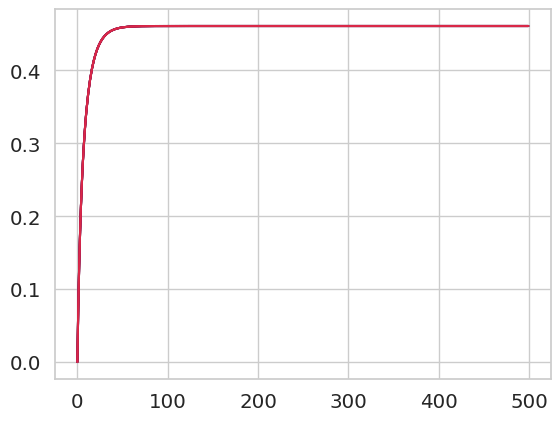

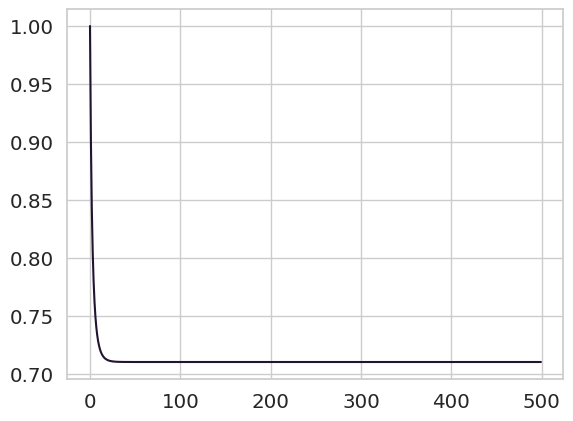

In [ ]:
plt.plot(all_all_gammas[-1])
plt.show()

plt.plot(losses)
plt.show()

In [ ]:
def simulate_opt_steps(D,P,T, sigma = 0.0, iter_steps = 100, step_size = 0.01, opt_init = False):

  if opt_init:
    etas = 0.01 * jnp.linspace(1,T,T)**(-0.5)
  else:
    etas = jnp.zeros(T)

  X = random.normal(random.PRNGKey(0), (D,P))
  w_star = jnp.ones(D)
  y = X.T @ w_star / jnp.sqrt(D) + sigma * random.normal(random.PRNGKey(1), (P,))



  def loss_fn(etas ):

    beta_hat = jnp.zeros(D)

    for t, eta in enumerate(etas):

      beta_hat += eta *  X @ ( y -  X.T @ beta_hat ) / P * jnp.sqrt(D)

    return jnp.mean( (beta_hat - w_star)**2 )


  grad_fn = jit(grad(loss_fn))

  all_etas = [ ]
  for n in range(iter_steps):
    all_etas += [etas]
    etas = etas - step_size * grad_fn(etas)

  return all_etas

In [ ]:
D = 100
P = 120
T = 120
sigma = 0.25
all_etas =  simulate_opt_steps(D,P,T, sigma = sigma, iter_steps = 250)

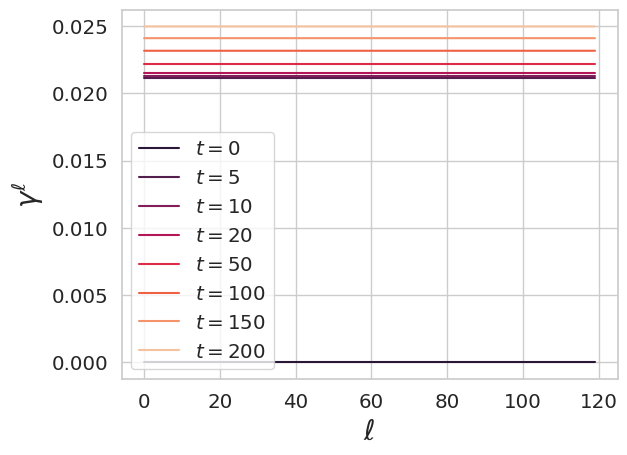

In [ ]:
nvals = [0, 5, 10, 20, 50, 100, 150,200]
sns.set_palette("rocket", n_colors=len(nvals))
for n in nvals:
  plt.plot(all_etas[n], label = r'$t = %d$' % n)
plt.legend()
plt.xlabel(r'$\ell$',fontsize = 20)
plt.ylabel(r'$\gamma^\ell$',fontsize = 20)
plt.savefig('untied_RRS_isotropic.pdf',bbox_inches = 'tight')
plt.show()


In [ ]:
D = 100
P = 120
T = 120
sigma = 0.25
all_etas =  simulate_opt_steps(D,P,T, sigma = sigma, iter_steps = 250, opt_init = True)

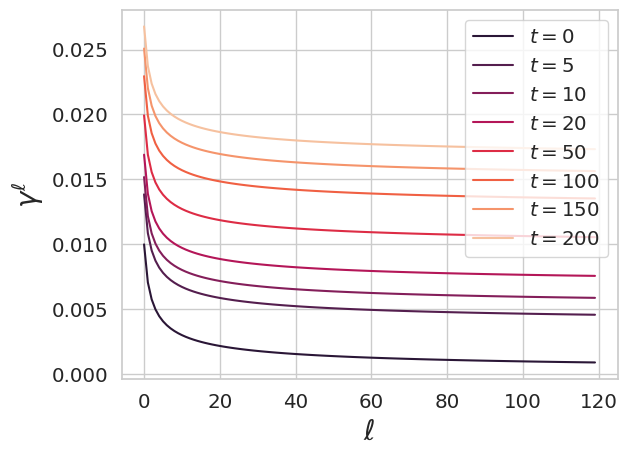

In [ ]:
nvals = [0, 5, 10, 20, 50, 100, 150,200]
sns.set_palette("rocket", n_colors=len(nvals))
for n in nvals:
  plt.plot(all_etas[n], label = r'$t = %d$' % n)
plt.legend()
plt.xlabel(r'$\ell$',fontsize = 20)
plt.ylabel(r'$\gamma^\ell$',fontsize = 20)
plt.savefig('untied_RRS_isotropic_nonequal_condition.pdf',bbox_inches = 'tight')
plt.show()


In [ ]:
def simulate_opt_steps_spectral(D,P,T, sigma = 0.0, iter_steps = 100, step_size = 0.01, opt_init = False):

  if opt_init:
    etas = 0.01 * jnp.linspace(1,T,T)**(-0.5)
  else:
    etas = jnp.zeros(T)

  X = jnp.einsum('i,ij->ij',jnp.linspace(1,D,D)**(-0.5) , random.normal(random.PRNGKey(0), (D,P)))
  w_star = jnp.ones(D)
  y = X.T @ w_star / jnp.sqrt(D) + sigma * random.normal(random.PRNGKey(1), (P,))



  def loss_fn(etas ):

    beta_hat = jnp.zeros(D)

    for t, eta in enumerate(etas):

      beta_hat += eta *  X @ ( y -  X.T @ beta_hat ) / P * jnp.sqrt(D)

    return jnp.mean( (beta_hat - w_star)**2 )


  grad_fn = jit(grad(loss_fn))

  all_etas = [ ]
  for n in range(iter_steps):
    all_etas += [etas]
    etas = etas - step_size * grad_fn(etas)

  return all_etas

In [ ]:
D = 100
P = 120
T = 120
sigma = 0.25
all_etas =  simulate_opt_steps_spectral(D,P,T, sigma = sigma, iter_steps = 250)

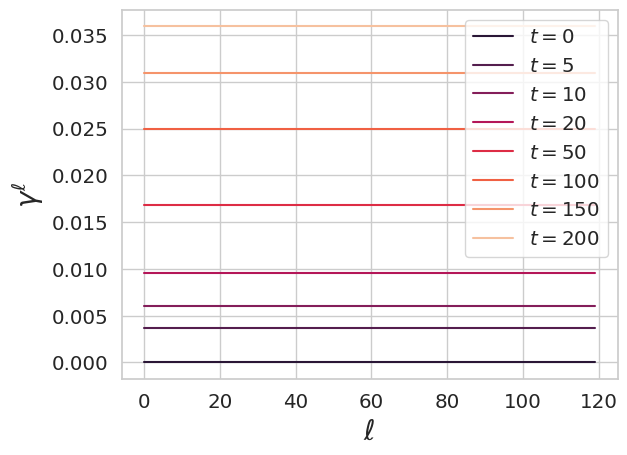

In [ ]:
nvals = [0, 5, 10, 20, 50, 100, 150,200]
sns.set_palette("rocket", n_colors=len(nvals))
for n in nvals:
  plt.plot(all_etas[n], label = r'$t = %d$' % n)
plt.legend()
plt.xlabel(r'$\ell$',fontsize = 20)
plt.ylabel(r'$\gamma^\ell$',fontsize = 20)
plt.savefig('untied_RRS_isotropic_nonequal_condition.pdf',bbox_inches = 'tight')
plt.show()